In [1]:
import torch

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Current Device: {torch.cuda.current_device()}")
    print(f"VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3060
GPU Count: 1
CUDA Version: 12.8
Current Device: 0
VRAM Total: 12.00 GB


In [2]:
# Core libraries
import os
import sys
import json
import copy
import pickle
import warnings
import gc
from datetime import datetime
import numpy as np
import pandas as pd
from pathlib import Path
import shutil
from collections import defaultdict, Counter
import random
import time
from tqdm import tqdm

# Image processing
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import timm

# Metrics and visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

# Kaggle datasets
import kagglehub

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set device for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Output directory for training results
OUTPUT_DIR = Path('training_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ All libraries imported succeful")

/home/sufi/miniconda3/envs/organized/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
✅ All libraries imported succeful


In [3]:
import cv2
import pandas as pd
from torch.utils.data import Dataset

In [4]:
# ============================================================
# CELL L1 (FIXED): Install LoRA dependencies
# ============================================================
import subprocess, os

print("📦 Installing dependencies...")

# Install one by one so we can see which one hangs
installs = [
    "pip install -q diffusers==0.27.2",
    "pip install -q accelerate",
    "pip install -q transformers",
    "pip install -q datasets",
    "pip install -q ftfy",
    "pip install -q tensorboard",
]

for cmd in installs:
    print(f"   Running: {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=120)
    if result.returncode == 0:
        print(f"   ✅ Done")
    else:
        print(f"   ❌ Failed: {result.stderr[-200:]}")

# Skip xformers — not essential for RTX 3060 with 12.9GB
print("\n⏭️  Skipping xformers (not required with 12.9GB VRAM)")

# Download training script
LORA_DIR = "/home/sufi/lora_training"
os.makedirs(LORA_DIR, exist_ok=True)

script_path = f"{LORA_DIR}/train_text_to_image_lora.py"
if not os.path.exists(script_path):
    print("\n⬇️  Downloading training script...")
    url = "https://raw.githubusercontent.com/huggingface/diffusers/v0.27.2/examples/text_to_image/train_text_to_image_lora.py"
    result = subprocess.run(f"wget -q {url} -O {script_path}", shell=True, timeout=60)
    if result.returncode == 0:
        print(f"✅ Script saved: {script_path}")
    else:
        print("❌ wget failed — check internet connection")
else:
    print(f"✅ Script already exists: {script_path}")

# Configure accelerate
accel_config = """compute_environment: LOCAL_MACHINE
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: all
machine_rank: 0
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_bonded_devices: true
use_cpu: false
"""
os.makedirs(os.path.expanduser("~/.cache/huggingface/accelerate"), exist_ok=True)
with open(os.path.expanduser("~/.cache/huggingface/accelerate/default_config.yaml"), "w") as f:
    f.write(accel_config)

print("✅ Accelerate configured!")
print("✅ CELL L1 COMPLETE!")

📦 Installing dependencies...
   Running: pip install -q diffusers==0.27.2
   ✅ Done
   Running: pip install -q accelerate
   ✅ Done
   Running: pip install -q transformers
   ✅ Done
   Running: pip install -q datasets
   ✅ Done
   Running: pip install -q ftfy
   ✅ Done
   Running: pip install -q tensorboard
   ✅ Done

⏭️  Skipping xformers (not required with 12.9GB VRAM)
✅ Script already exists: /home/sufi/lora_training/train_text_to_image_lora.py
✅ Accelerate configured!
✅ CELL L1 COMPLETE!


In [3]:
print("="*70)
print("📥 DOWNLOADING DATASETS")
print("="*70)

# Dataset 1: MVTec AD
print("\n[1/3] Downloading MVTec AD Dataset...")
print("      (~5,000 images - Industrial Anomaly Detection)")
try:
    mvtec_path = kagglehub.dataset_download("hycloud/mvtech-anomaly-detection")
    print(f"   ✅ Done: {mvtec_path}")
    MVTEC_PATH = Path(mvtec_path)
except Exception as e:
    print(f"   ❌ Error: {e}")
    MVTEC_PATH = None

# Dataset 2: Casting Product (7,348 images)
print("\n[2/3] Downloading Casting Product Dataset...")
print("      (7,348 images - Metal Casting Defects)")
try:
    casting_path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")
    print(f"   ✅ Done: {casting_path}")
    CASTING_PATH = Path(casting_path)
except Exception as e:
    print(f"   ❌ Error: {e}")
    CASTING_PATH = None

# Dataset 3: Magnetic Tile (1,344 images)
print("\n[3/3] Downloading Magnetic Tile Dataset...")
print("      (1,344 images - Surface Texture Defects)")
try:
    magnetic_path = kagglehub.dataset_download("alex000kim/magnetic-tile-surface-defects")
    print(f"   ✅ Done: {magnetic_path}")
    MAGNETIC_PATH = Path(magnetic_path)
except Exception as e:
    print(f"   ❌ Error: {e}")
    MAGNETIC_PATH = None

print("\n" + "="*70)
print("✅ DOWNLOADS COMPLETE!")
print("="*70)

📥 DOWNLOADING DATASETS

[1/3] Downloading MVTec AD Dataset...
      (~5,000 images - Industrial Anomaly Detection)
   ✅ Done: /home/sufi/.cache/kagglehub/datasets/hycloud/mvtech-anomaly-detection/versions/1

[2/3] Downloading Casting Product Dataset...
      (7,348 images - Metal Casting Defects)
   ✅ Done: /home/sufi/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2

[3/3] Downloading Magnetic Tile Dataset...
      (1,344 images - Surface Texture Defects)
   ✅ Done: /home/sufi/.cache/kagglehub/datasets/alex000kim/magnetic-tile-surface-defects/versions/1

✅ DOWNLOADS COMPLETE!


In [6]:
print("="*70)
print("🔄 STEP 7: ANALYZING MVTEC AD DATASET")
print("="*70)

mvtec_data = {'normal': [], 'defect': [], 'stats': {}}

# Navigate to the actual dataset folder
MVTEC_ROOT = MVTEC_PATH / 'mvtech_anomaly_detection'

if not MVTEC_ROOT.exists():
    print("⚠️ mvtech_anomaly_detection folder not found!")
else:
    for cat in tqdm([d for d in MVTEC_ROOT.iterdir() if d.is_dir()], desc="Processing MVTec"):
        cat_name = cat.name
        mvtec_data['stats'][cat_name] = {'normal': 0, 'defect': 0}
        
        # Train/good folder (Normal images)
        train_good = cat / 'train' / 'good'
        if train_good.exists():
            for img in train_good.glob('*.png'):
                mvtec_data['normal'].append({
                    'path': str(img), 'dataset': 'mvtec', 
                    'category': cat_name, 'defect_type': 'good', 'label': 0
                })
            mvtec_data['stats'][cat_name]['normal'] += len(list(train_good.glob('*.png')))
        
        # Test folder
        test_dir = cat / 'test'
        if test_dir.exists():
            for defect_folder in test_dir.iterdir():
                if defect_folder.is_dir():
                    imgs = list(defect_folder.glob('*.png'))
                    dtype = defect_folder.name
                    
                    if dtype == 'good':
                        for img in imgs:
                            mvtec_data['normal'].append({
                                'path': str(img), 'dataset': 'mvtec',
                                'category': cat_name, 'defect_type': 'good', 'label': 0
                            })
                        mvtec_data['stats'][cat_name]['normal'] += len(imgs)
                    else:
                        for img in imgs:
                            mvtec_data['defect'].append({
                                'path': str(img), 'dataset': 'mvtec',
                                'category': cat_name, 'defect_type': dtype, 'label': 1
                            })
                        mvtec_data['stats'][cat_name]['defect'] += len(imgs)

    print(f"\n✅ MVTec AD - Normal: {len(mvtec_data['normal'])}, Defect: {len(mvtec_data['defect'])}")

print("\n✅ STEP 7 COMPLETE!")

🔄 STEP 7: ANALYZING MVTEC AD DATASET


Processing MVTec: 100%|██████████| 15/15 [00:00<00:00, 436.04it/s]


✅ MVTec AD - Normal: 4096, Defect: 1258

✅ STEP 7 COMPLETE!


In [7]:
print("="*70)
print("🔄 STEP 8: ANALYZING CASTING PRODUCT DATASET")
print("="*70)

casting_data = {'normal': [], 'defect': [], 'stats': {'normal': 0, 'defect': 0}}

total_normal = 0
total_defect = 0

# ============================================================
# Process casting_512x512 folder
# ============================================================
casting_512_path = CASTING_PATH / 'casting_512x512' / 'casting_512x512'

if casting_512_path.exists():
    print(f"\n   Processing: casting_512x512")
    
    # Process normal images (ok_front)
    normal_dir = casting_512_path / 'ok_front'
    if normal_dir.exists():
        normal_images = (list(normal_dir.glob('*.jpeg')) + 
                       list(normal_dir.glob('*.jpg')) + 
                       list(normal_dir.glob('*.png')))
        print(f"      Normal images: {len(normal_images)}")
        
        for img in tqdm(normal_images, desc="   casting_512x512 normal"):
            casting_data['normal'].append({
                'path': str(img), 'dataset': 'casting',
                'category': 'casting_product', 'defect_type': 'ok', 'label': 0
            })
            total_normal += 1
    
    # Process defect images (def_front)
    defect_dir = casting_512_path / 'def_front'
    if defect_dir.exists():
        defect_images = (list(defect_dir.glob('*.jpeg')) + 
                       list(defect_dir.glob('*.jpg')) + 
                       list(defect_dir.glob('*.png')))
        print(f"      Defect images: {len(defect_images)}")
        
        for img in tqdm(defect_images, desc="   casting_512x512 defect"):
            casting_data['defect'].append({
                'path': str(img), 'dataset': 'casting',
                'category': 'casting_product', 'defect_type': 'defect', 'label': 1
            })
            total_defect += 1

# ============================================================
# Process casting_data folder (train and test splits)
# ============================================================
casting_data_path = CASTING_PATH / 'casting_data' / 'casting_data'

if casting_data_path.exists():
    print(f"\n   Processing: casting_data (train + test)")
    
    # Process both train and test folders
    for split in ['train', 'test']:
        split_path = casting_data_path / split
        
        if split_path.exists():
            print(f"\n      Processing: {split}")
            
            # Process normal images (ok_front)
            normal_dir = split_path / 'ok_front'
            if normal_dir.exists():
                normal_images = (list(normal_dir.glob('*.jpeg')) + 
                               list(normal_dir.glob('*.jpg')) + 
                               list(normal_dir.glob('*.png')))
                print(f"         Normal images: {len(normal_images)}")
                
                for img in tqdm(normal_images, desc=f"      {split} normal"):
                    casting_data['normal'].append({
                        'path': str(img), 'dataset': 'casting',
                        'category': 'casting_product', 'defect_type': 'ok', 'label': 0
                    })
                    total_normal += 1
            
            # Process defect images (def_front)
            defect_dir = split_path / 'def_front'
            if defect_dir.exists():
                defect_images = (list(defect_dir.glob('*.jpeg')) + 
                               list(defect_dir.glob('*.jpg')) + 
                               list(defect_dir.glob('*.png')))
                print(f"         Defect images: {len(defect_images)}")
                
                for img in tqdm(defect_images, desc=f"      {split} defect"):
                    casting_data['defect'].append({
                        'path': str(img), 'dataset': 'casting',
                        'category': 'casting_product', 'defect_type': 'defect', 'label': 1
                    })
                    total_defect += 1

casting_data['stats']['normal'] = total_normal
casting_data['stats']['defect'] = total_defect

print(f"\n✅ Casting Product - Normal: {total_normal}, Defect: {total_defect}")
print(f"   Total: {total_normal + total_defect}")

print("\n✅ STEP 8 COMPLETE!")

🔄 STEP 8: ANALYZING CASTING PRODUCT DATASET

   Processing: casting_512x512
      Normal images: 519


   casting_512x512 normal: 100%|██████████| 519/519 [00:00<00:00, 1911188.57it/s]


      Defect images: 781


   casting_512x512 defect: 100%|██████████| 781/781 [00:00<00:00, 1299385.73it/s]



   Processing: casting_data (train + test)

      Processing: train
         Normal images: 2875


...


      Processing: test
         Normal images: 262


      test normal: 100%|██████████| 262/262 [00:00<00:00, 1766732.55it/s]


         Defect images: 453


      test defect: 100%|██████████| 453/453 [00:00<00:00, 2060758.91it/s]


✅ Casting Product - Normal: 3656, Defect: 4992
   Total: 8648

✅ STEP 8 COMPLETE!


In [8]:
print("="*70)
print("🔄 STEP 9: ANALYZING MAGNETIC TILE DATASET")
print("="*70)

magnetic_data = {'normal': [], 'defect': [], 'stats': {}}

# Find all MT_* folders
mt_folders = [d for d in MAGNETIC_PATH.iterdir() if d.is_dir() and 'MT_' in d.name]

print(f"   Found {len(mt_folders)} MT_* folders")

for item in tqdm(mt_folders, desc="Processing Magnetic Tile"):
    dtype = item.name
    magnetic_data['stats'][dtype] = 0
    
    # Images are in the 'Imgs' subdirectory
    imgs_dir = item / 'Imgs'
    
    if not imgs_dir.exists():
        print(f"   ⚠️ Warning: {dtype}/Imgs not found, skipping...")
        continue
    
    # Look for images with various extensions
    images = (list(imgs_dir.glob('*.jpg')) + 
              list(imgs_dir.glob('*.png')) + 
              list(imgs_dir.glob('*.bmp')) + 
              list(imgs_dir.glob('*.jpeg')) +
              list(imgs_dir.glob('*.JPG')) +
              list(imgs_dir.glob('*.PNG')) +
              list(imgs_dir.glob('*.BMP')))
    
    # Determine if normal or defect
    is_normal = 'free' in dtype.lower()
    
    for img in images:
        if is_normal:
            magnetic_data['normal'].append({
                'path': str(img), 'dataset': 'magnetic',
                'category': 'magnetic_tile', 'defect_type': 'free', 'label': 0
            })
        else:
            magnetic_data['defect'].append({
                'path': str(img), 'dataset': 'magnetic',
                'category': 'magnetic_tile', 'defect_type': dtype.lower().replace('mt_', ''), 'label': 1
            })
    
    magnetic_data['stats'][dtype] = len(images)

print(f"\n✅ Magnetic Tile - Normal: {len(magnetic_data['normal'])}, Defect: {len(magnetic_data['defect'])}")
print(f"\n📊 Breakdown by type:")
for dtype, count in magnetic_data['stats'].items():
    status = "NORMAL" if 'free' in dtype.lower() else "DEFECT"
    print(f"   {dtype}: {count} images ({status})")

print("\n✅ STEP 9 COMPLETE!")

🔄 STEP 9: ANALYZING MAGNETIC TILE DATASET
   Found 6 MT_* folders


Processing Magnetic Tile: 100%|██████████| 6/6 [00:00<00:00, 298.92it/s]


✅ Magnetic Tile - Normal: 1904, Defect: 784

📊 Breakdown by type:
   MT_Crack: 114 images (DEFECT)
   MT_Fray: 64 images (DEFECT)
   MT_Break: 170 images (DEFECT)
   MT_Free: 1904 images (NORMAL)
   MT_Blowhole: 230 images (DEFECT)
   MT_Uneven: 206 images (DEFECT)

✅ STEP 9 COMPLETE!


In [9]:
print("="*70)
print("📊 STEP 10: COMBINING ALL DATASETS")
print("="*70)

# Combine all data
all_normal = mvtec_data['normal'] + casting_data['normal'] + magnetic_data['normal']
all_defect = mvtec_data['defect'] + casting_data['defect'] + magnetic_data['defect']
all_data = all_normal + all_defect

# Create DataFrame
df = pd.DataFrame(all_data)

print(f"\n📊 Combined Dataset Statistics:")
print(f"   Total Images: {len(df):,}")
print(f"   Normal Images: {len(all_normal):,}")
print(f"   Defect Images: {len(all_defect):,}")
print(f"\n   By Dataset:")
print(f"   - MVTec AD: {len(mvtec_data['normal']) + len(mvtec_data['defect']):,}")
print(f"   - Casting Product: {len(casting_data['normal']) + len(casting_data['defect']):,}")
print(f"   - Magnetic Tile: {len(magnetic_data['normal']) + len(magnetic_data['defect']):,}")

# Display first few rows
print("\n📋 DataFrame Preview:")
print(df.head(10))

print("\n✅ STEP 10 COMPLETE!")

📊 STEP 10: COMBINING ALL DATASETS

📊 Combined Dataset Statistics:
   Total Images: 16,690
   Normal Images: 9,656
   Defect Images: 7,034

   By Dataset:
   - MVTec AD: 5,354
   - Casting Product: 8,648
   - Magnetic Tile: 2,688

📋 DataFrame Preview:
                                                path dataset category  \
0  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
1  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
2  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
3  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
4  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
5  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
6  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
7  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
8  /home/sufi/.cache/kagglehub/datasets/hycloud/m...   mvtec   bottle   
9  /home/sufi/.cach

In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 77 — GLOBALS (run FIRST, always)                              ║
# ╚══════════════════════════════════════════════════════════════════════╝
 
import os, gc, torch, numpy as np, pandas as pd
from pathlib import Path
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
 
# ── Semantic defect groups ────────────────────────────────────────────
SEMANTIC_GROUPS = [
    'contamination', 'cut', 'deformation', 'fracture',
    'hole_void', 'minor_defect', 'scratch', 'surface_quality'
]
 
NUM_DEFECT_TYPES  = len(SEMANTIC_GROUPS)   # 8
NUM_PRODUCT_TYPES = 17
 
DEFECT_TYPE_TO_IDX = {name: idx for idx, name in enumerate(SEMANTIC_GROUPS)}
IDX_TO_DEFECT_TYPE = {idx: name for idx, name in enumerate(SEMANTIC_GROUPS)}
 
# ── Raw label → semantic group mapping ───────────────────────────────
DEFECT_GROUP_MAP = {
    # fracture
    'crack':          'fracture',
    'fracture':       'fracture',
    'faulty_imprint': 'fracture',
    # hole_void
    'hole':           'hole_void',
    'void':           'hole_void',
    'pit':            'hole_void',
    'blowhole':       'hole_void',
    # scratch
    'scratch':        'scratch',
    'score':          'scratch',
    # surface_quality
    'stain':          'surface_quality',
    'color':          'surface_quality',
    'rough':          'surface_quality',
    'uneven':         'surface_quality',
    'inclusion':      'surface_quality',
    'discolor':       'surface_quality',
    'pilling':        'surface_quality',
    # deformation
    'bent':           'deformation',
    'bent_lead':      'deformation',
    'squeeze':        'deformation',
    'deformation':    'deformation',
    # contamination
    'contamination':  'contamination',
    'glue':           'contamination',
    'oil':            'contamination',
    'glue_strip':     'contamination',
    'liquid':         'contamination',
    'metal_contamination': 'contamination',
    # minor_defect
    'missing':        'minor_defect',
    'misplaced':      'minor_defect',
    'flip':           'minor_defect',
    'missing_hole':   'minor_defect',
    'thread':         'minor_defect',
    'cable_swap':     'minor_defect',
    'combined':       'minor_defect',
    # cut
    'cut':            'cut',
}
 
# ── Product type mapping (fill from your dataset) ────────────────────
PRODUCT_TYPE_TO_IDX = {}
IDX_TO_PRODUCT_TYPE = {}
 
print(f"✅ CELL 77 COMPLETE")
print(f"   NUM_DEFECT_TYPES  : {NUM_DEFECT_TYPES}")
print(f"   NUM_PRODUCT_TYPES : {NUM_PRODUCT_TYPES}")
print(f"   Semantic groups   : {SEMANTIC_GROUPS}")
 

Device: cuda
✅ CELL 77 COMPLETE
   NUM_DEFECT_TYPES  : 8
   NUM_PRODUCT_TYPES : 17
   Semantic groups   : ['contamination', 'cut', 'deformation', 'fracture', 'hole_void', 'minor_defect', 'scratch', 'surface_quality']


In [22]:
# ============================================================
# CELL L2: Prepare contamination image dataset for LoRA
# ============================================================
import pandas as pd, os, shutil
from PIL import Image

META_PATH  = "/home/sufi/merged_dataset_metadata.csv"
LORA_DIR   = "/home/sufi/lora_training"
CLASS_NAME = "contamination"
DATA_DIR   = f"{LORA_DIR}/datasets/{CLASS_NAME}"
IMG_DIR    = f"{DATA_DIR}/images"

os.makedirs(IMG_DIR, exist_ok=True)

df = pd.read_csv(META_PATH)

# ── Get all raw labels that map to contamination ─────────────
raw_labels = [k for k, v in DEFECT_GROUP_MAP.items() if v == CLASS_NAME]
print(f"📋 Raw labels mapped to '{CLASS_NAME}': {raw_labels}")

# ── Use TRAIN split only ──────────────────────────────────────
cont_df = df[df['defect_type'].isin(raw_labels) & (df['split'] == 'train')]
print(f"🎯 Train images found: {len(cont_df)}")

# ── Caption map: raw label → descriptive prompt ───────────────
CAPTION_MAP = {
    'contamination':       "industrial surface defect, contamination, foreign material on product surface",
    'metal_contamination': "industrial surface defect, metal contamination, metallic particle on surface",
    'glue':                "industrial surface defect, glue contamination, adhesive residue on product",
    'glue_strip':          "industrial surface defect, glue strip contamination, adhesive strip on surface",
    'oil':                 "industrial surface defect, oil contamination, oil stain on product surface",
    'liquid':              "industrial surface defect, liquid contamination, liquid stain on surface",
}

# ── Copy images + write captions ─────────────────────────────
copied = 0
skipped = 0
metadata_rows = []

for idx, row in cont_df.iterrows():
    src = row['path']
    raw_label = row['defect_type']

    if not os.path.exists(src):
        skipped += 1
        continue

    # Standardize to 512x512 PNG (required by SD)
    dst_name = f"{CLASS_NAME}_{copied:04d}.png"
    dst_path = f"{IMG_DIR}/{dst_name}"

    try:
        img = Image.open(src).convert("RGB")
        img = img.resize((512, 512), Image.LANCZOS)
        img.save(dst_path)

        # Caption file (same name, .txt)
        caption = CAPTION_MAP.get(raw_label,
            f"industrial surface defect, {CLASS_NAME}, close-up photograph")
        caption_path = f"{IMG_DIR}/{dst_name.replace('.png', '.txt')}"
        with open(caption_path, 'w') as f:
            f.write(caption)

        metadata_rows.append({
            'file_name':  dst_name,
            'raw_label':  raw_label,
            'caption':    caption,
            'src':        src
        })
        copied += 1

    except Exception as e:
        print(f"   ⚠️ Error on {src}: {e}")
        skipped += 1

# ── Save metadata.jsonl (required by diffusers dataloader) ────
import json
jsonl_path = f"{IMG_DIR}/metadata.jsonl"
with open(jsonl_path, 'w') as f:
    for row in metadata_rows:
        f.write(json.dumps({
            "file_name": row['file_name'],
            "text":      row['caption']
        }) + "\n")

print(f"\n✅ Dataset prepared!")
print(f"   Images copied : {copied}")
print(f"   Skipped       : {skipped}")
print(f"   Output dir    : {IMG_DIR}")
print(f"   Metadata      : {jsonl_path}")
print(f"\n📋 Caption distribution:")
cap_dist = {}
for r in metadata_rows:
    cap_dist[r['raw_label']] = cap_dist.get(r['raw_label'], 0) + 1
for k, v in cap_dist.items():
    print(f"   {k:<25} {v} images")

# ── Quick visual check ────────────────────────────────────────
print(f"\n🖼️  Sample (first 3 images):")
for r in metadata_rows[:3]:
    print(f"   {r['file_name']} ← {r['raw_label']}")
    print(f"   Caption: {r['caption'][:60]}...")

print("\n✅ CELL L2 COMPLETE!")

📋 Raw labels mapped to 'contamination': ['contamination', 'metal_contamination', 'glue', 'glue_strip', 'liquid', 'oil']
🎯 Train images found: 101

✅ Dataset prepared!
   Images copied : 101
   Skipped       : 0
   Output dir    : /home/sufi/lora_training/datasets/contamination/images
   Metadata      : /home/sufi/lora_training/datasets/contamination/images/metadata.jsonl

📋 Caption distribution:
   glue_strip                11 images
   contamination             34 images
   oil                       11 images
   glue                      20 images
   liquid                    6 images
   metal_contamination       19 images

🖼️  Sample (first 3 images):
   contamination_0000.png ← glue_strip
   Caption: industrial surface defect, glue strip contamination, adhesiv...
   contamination_0001.png ← contamination
   Caption: industrial surface defect, contamination, foreign material o...
   contamination_0002.png ← contamination
   Caption: industrial surface defect, contamination, foreign m

In [23]:
# ============================================================
# CELL L1B: Fix accelerate config
# ============================================================
import os

# Minimal config — no TPU keys
accel_config = """compute_environment: LOCAL_MACHINE
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: all
machine_rank: 0
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
use_cpu: false
"""

config_path = os.path.expanduser("~/.cache/huggingface/accelerate/default_config.yaml")
with open(config_path, "w") as f:
    f.write(accel_config)

print(f"✅ Config fixed: {config_path}")
print(f"\n📋 Contents:")
print(accel_config)
print("✅ Now re-run CELL L3!")

✅ Config fixed: /home/sufi/.cache/huggingface/accelerate/default_config.yaml

📋 Contents:
compute_environment: LOCAL_MACHINE
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: all
machine_rank: 0
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
use_cpu: false

✅ Now re-run CELL L3!


In [24]:
import subprocess
result = subprocess.run("pip install -q peft", shell=True, capture_output=True, text=True)
print("✅ peft installed!" if result.returncode == 0 else f"❌ Failed: {result.stderr}")

✅ peft installed!


In [25]:
import subprocess

print("🔧 Pinning all versions to known working set...")

# Order matters — uninstall first, then reinstall pinned
cmds = [
    "pip uninstall -y diffusers transformers huggingface_hub accelerate",
    "pip install -q 'huggingface_hub==0.24.0'",
    "pip install -q 'transformers==4.44.2'",
    "pip install -q 'diffusers==0.29.2'",
    "pip install -q 'accelerate==0.33.0'",
    "pip install -q 'peft==0.12.0'",
]

for cmd in cmds:
    print(f"\n   {cmd}")
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=180)
    print(f"   {'✅ Done' if r.returncode==0 else '❌ ' + r.stderr[-150:]}")

# Download matching script
print("\n⬇️  Downloading matching training script (v0.29.2)...")
url = "https://raw.githubusercontent.com/huggingface/diffusers/v0.29.2/examples/text_to_image/train_text_to_image_lora.py"
r = subprocess.run(
    f"wget -q {url} -O /home/sufi/lora_training/train_text_to_image_lora.py",
    shell=True, timeout=60
)
print(f"   {'✅ Script updated' if r.returncode==0 else '❌ wget failed'}")

# Verify all imports work
print("\n🔍 Verifying imports...")
test = """
import diffusers, transformers, accelerate, peft, huggingface_hub
print(f'diffusers    : {diffusers.__version__}')
print(f'transformers : {transformers.__version__}')
print(f'accelerate   : {accelerate.__version__}')
print(f'peft         : {peft.__version__}')
print(f'huggingface_hub: {huggingface_hub.__version__}')
from diffusers import StableDiffusionPipeline
print('✅ StableDiffusionPipeline import OK')
"""
r = subprocess.run(f'python -c "{test}"', shell=True, capture_output=True, text=True)
print(r.stdout if r.returncode==0 else f"❌ {r.stderr[-300:]}")

print("\n✅ Now re-run CELL L3!")

🔧 Pinning all versions to known working set...

   pip uninstall -y diffusers transformers huggingface_hub accelerate
   ✅ Done

   pip install -q 'huggingface_hub==0.24.0'
   ✅ Done

   pip install -q 'transformers==4.44.2'
   ✅ Done

   pip install -q 'diffusers==0.29.2'
   ✅ Done

   pip install -q 'accelerate==0.33.0'
   ✅ Done

   pip install -q 'peft==0.12.0'
   ✅ Done

⬇️  Downloading matching training script (v0.29.2)...
   ✅ Script updated

🔍 Verifying imports...
diffusers    : 0.29.2
transformers : 4.44.2
accelerate   : 0.33.0
peft         : 0.12.0
huggingface_hub: 0.24.0
✅ StableDiffusionPipeline import OK


✅ Now re-run CELL L3!


In [ ]:
cat > /home/sufi/lora_training/train_lora.py << 'EOF'
import os, torch
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from peft import LoraConfig, get_peft_model
from PIL import Image
from pathlib import Path
import torch.nn.functional as F

# ── Config ────────────────────────────────────────────────────
IMG_DIR    = "/home/sufi/lora_training/datasets/contamination/images"
OUTPUT_DIR = "/home/sufi/lora_training/weights/contamination"
BASE_MODEL = "runwayml/stable-diffusion-v1-5"
EPOCHS     = 100
LR         = 1e-4
BATCH_SIZE = 2
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load components ───────────────────────────────────────────
print("Loading model components...")
tokenizer    = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder="text_encoder").cuda()
vae          = AutoencoderKL.from_pretrained(BASE_MODEL, subfolder="vae").cuda().half()
unet         = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder="unet").cuda()
scheduler    = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder="scheduler")

# ── Freeze base weights ───────────────────────────────────────
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# ── Inject LoRA into UNet via PEFT ───────────────────────────
lora_config = LoraConfig(
    r=4,
    lora_alpha=4,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.0,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()), lr=LR
)

# ── Dataset ───────────────────────────────────────────────────
class DefectDataset(Dataset):
    def __init__(self, img_dir):
        self.imgs = sorted([
            f for f in Path(img_dir).glob("*.png")
            if "metadata" not in str(f)
        ])
        self.txts = {p: p.with_suffix(".txt") for p in self.imgs}
        self.transform = transforms.Compose([
            transforms.Resize(512),
            transforms.CenterCrop(512),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = self.transform(Image.open(self.imgs[i]).convert("RGB"))
        cap = open(self.txts[self.imgs[i]]).read().strip()
        return img, cap

dataset = DefectDataset(IMG_DIR)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print(f"Dataset: {len(dataset)} images")

scaler = torch.amp.GradScaler('cuda')

# ── Training loop ─────────────────────────────────────────────
print("Starting LoRA training...")
for epoch in range(EPOCHS):
    total_loss = 0
    for imgs, captions in loader:
        imgs = imgs.cuda().half()

        with torch.no_grad():
            latents = vae.encode(imgs).latent_dist.sample() * 0.18215

        noise     = torch.randn_like(latents)
        timesteps = torch.randint(
            0, scheduler.config.num_train_timesteps,
            (latents.shape[0],), device="cuda"
        ).long()
        noisy_latents = scheduler.add_noise(latents, noise, timesteps)

        with torch.no_grad():
            tokens  = tokenizer(
                list(captions), padding="max_length",
                max_length=77, truncation=True,
                return_tensors="pt"
            ).input_ids.cuda()
            text_emb = text_encoder(tokens)[0]

        with torch.amp.autocast('cuda'):
            pred = unet(noisy_latents, timesteps, text_emb).sample
            loss = F.mse_loss(pred.float(), noise.float())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    avg = total_loss / len(loader)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  loss={avg:.4f}")

# ── Save LoRA weights ─────────────────────────────────────────
unet.save_pretrained(OUTPUT_DIR)
print(f"✅ LoRA saved to {OUTPUT_DIR}")
EOF
echo "✅ Script written. Now running..."
python /home/sufi/lora_training/train_lora.py

In [ ]:
cat > /home/sufi/lora_training/generate.py << 'EOF'
import torch, os
from diffusers import StableDiffusionPipeline
from peft import PeftModel
from PIL import Image

LORA_DIR   = "/home/sufi/lora_training"
CLASS_NAME = "contamination"
OUT_DIR    = f"{LORA_DIR}/synthetic/{CLASS_NAME}"
BASE_MODEL = "runwayml/stable-diffusion-v1-5"
os.makedirs(OUT_DIR, exist_ok=True)

# Load pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL, torch_dtype=torch.float16, safety_checker=None
).to("cuda")

# Load LoRA via PEFT directly onto unet
pipe.unet = PeftModel.from_pretrained(
    pipe.unet, f"{LORA_DIR}/weights/{CLASS_NAME}"
)
pipe.unet = pipe.unet.merge_and_unload()  # merge for faster inference

PROMPTS = [
    "industrial surface defect, contamination, foreign material on product surface",
    "industrial surface defect, metal contamination, metallic particle on surface",
    "industrial surface defect, glue contamination, adhesive residue on product",
    "industrial surface defect, oil contamination, oil stain on surface",
    "industrial surface defect, liquid contamination, liquid stain on surface",
]
NEG = "blurry, cartoon, text, watermark, normal surface, no defect"

print("Generating 399 images...")
for i in range(399):
    prompt = PROMPTS[i % len(PROMPTS)]
    image = pipe(prompt, negative_prompt=NEG,
                 num_inference_steps=30, guidance_scale=7.5,
                 generator=torch.Generator("cuda").manual_seed(i)).images[0]
    image.resize((224, 224)).save(f"{OUT_DIR}/syn_{i:04d}.png")
    if i % 50 == 0:
        print(f"  [{i}/399]")

print(f"✅ Done! Saved to {OUT_DIR}")
EOF
python /home/sufi/lora_training/generate.py

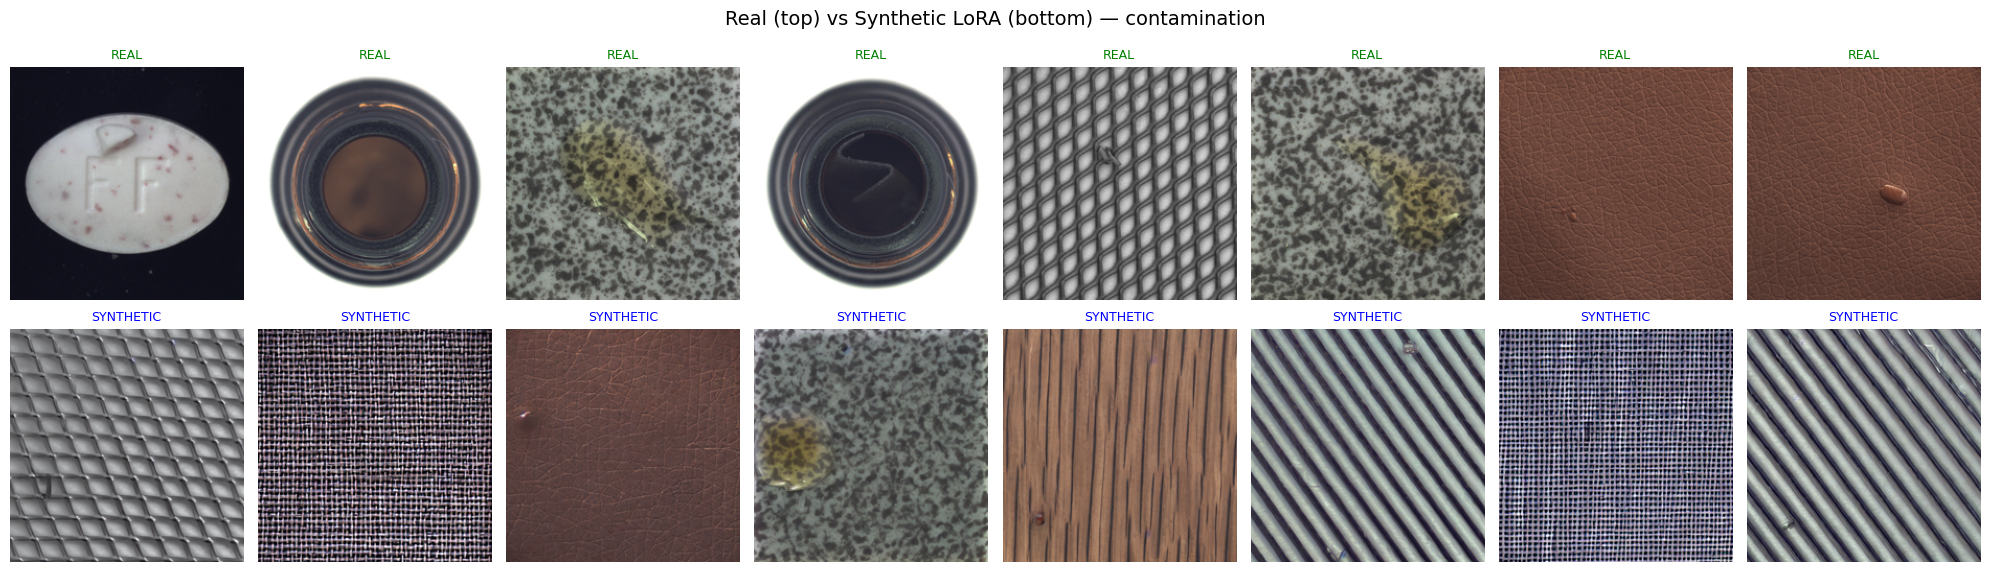

✅ Quality check saved: /home/sufi/lora_training/quality_check_contamination.png

👀 EXAMINE THE IMAGES:
   ✅ Good: defect texture visible, looks like real contamination
   ❌ Bad : random noise, no clear defect, totally different from real

   If GOOD → proceed to retrain EdgeNet with synthetic data
   If BAD  → increase epochs in CELL L3 (try 200) and retrain LoRA

✅ CELL L5 COMPLETE!


In [9]:
# ============================================================
# CELL L5: Compare real vs synthetic (sanity check)
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd, os, random
from PIL import Image

LORA_DIR   = "/home/sufi/lora_training"
CLASS_NAME = "contamination"
SYN_DIR    = f"{LORA_DIR}/synthetic/{CLASS_NAME}"
META_PATH  = "/home/sufi/merged_dataset_metadata.csv"

df = pd.read_csv(META_PATH)
raw_labels = [k for k, v in DEFECT_GROUP_MAP.items() if v == CLASS_NAME]
real_paths = df[df['defect_type'].isin(raw_labels) & (df['split']=='train')]['path'].tolist()
syn_paths  = [f"{SYN_DIR}/{f}" for f in sorted(os.listdir(SYN_DIR))[:8]]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("Real (top) vs Synthetic LoRA (bottom) — contamination", fontsize=14)

for i, path in enumerate(random.sample(real_paths, min(8, len(real_paths)))):
    img = Image.open(path).convert("RGB").resize((224, 224))
    axes[0, i].imshow(img)
    axes[0, i].set_title("REAL", fontsize=9, color='green')
    axes[0, i].axis('off')

for i, path in enumerate(syn_paths[:8]):
    img = Image.open(path).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].set_title("SYNTHETIC", fontsize=9, color='blue')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(f"{LORA_DIR}/quality_check_{CLASS_NAME}.png", dpi=150)
plt.show()

print(f"✅ Quality check saved: {LORA_DIR}/quality_check_{CLASS_NAME}.png")
print(f"\n👀 EXAMINE THE IMAGES:")
print(f"   ✅ Good: defect texture visible, looks like real contamination")
print(f"   ❌ Bad : random noise, no clear defect, totally different from real")
print(f"\n   If GOOD → proceed to retrain EdgeNet with synthetic data")
print(f"   If BAD  → increase epochs in CELL L3 (try 200) and retrain LoRA")
print(f"\n✅ CELL L5 COMPLETE!")

In [26]:
# ============================================================
# CELL AUG: Albumentations Synthetic Augmentation
# ============================================================
import pandas as pd, os, cv2, numpy as np
from pathlib import Path
import albumentations as A
from PIL import Image

print("="*60)
print("🔧 ALBUMENTATIONS SYNTHETIC AUGMENTATION")
print("="*60)

META_PATH  = "/home/sufi/merged_dataset_metadata.csv"
SYN_BASE   = "/home/sufi/lora_training/synthetic"
TARGET     = 500   # target per class

df = pd.read_csv(META_PATH)

# ── Classes needing augmentation (train counts) ───────────────
AUG_CLASSES = {
    'contamination':   101,
    'minor_defect':    110,
    'cut':             115,
    'deformation':     164,
    'scratch':         179,
    'surface_quality': 193,
    'hole_void':       231,
}

# ── Heavy augmentation pipeline ───────────────────────────────
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.ElasticTransform(
        alpha=120, sigma=120*0.05,
        alpha_affine=120*0.03, p=0.5
    ),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.4),
    A.OpticalDistortion(distort_limit=0.2, shift_limit=0.2, p=0.3),
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(
            hue_shift_limit=20, sat_shift_limit=30,
            val_shift_limit=20, p=1.0),
        A.RandomGamma(gamma_limit=(80, 120), p=1.0),
    ], p=0.7),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
        A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0),
    ], p=0.5),
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.Sharpen(alpha=(0.2, 0.5), p=1.0),
    ], p=0.3),
    A.CoarseDropout(
        max_holes=8, max_height=16, max_width=16,
        min_holes=2, fill_value=0, p=0.3
    ),
    A.Resize(224, 224),
])

# ── Generate per class ────────────────────────────────────────
summary = []
total_generated = 0

for class_name, train_count in AUG_CLASSES.items():
    n_needed = TARGET - train_count
    out_dir  = f"{SYN_BASE}/{class_name}"
    os.makedirs(out_dir, exist_ok=True)

    # Get raw labels for this class
    raw_labels = [k for k, v in DEFECT_GROUP_MAP.items() if v == class_name]
    train_df   = df[df['defect_type'].isin(raw_labels) & (df['split'] == 'train')]
    real_paths = train_df['path'].tolist()

    if len(real_paths) == 0:
        print(f"   ⚠️  {class_name}: no train images found!")
        continue

    print(f"\n📁 {class_name}")
    print(f"   Real train : {len(real_paths)}")
    print(f"   Generating : {n_needed}")

    generated = 0
    failed    = 0
    np.random.seed(42)

    while generated < n_needed:
        # Pick a random real image
        src_path = real_paths[generated % len(real_paths)]
        try:
            img = cv2.imread(src_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            aug = transform(image=img)['image']
            save_path = f"{out_dir}/aug_{class_name}_{generated:04d}.png"
            cv2.imwrite(save_path, cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))
            generated += 1
        except Exception as e:
            failed += 1
            if failed > 10:
                print(f"   ❌ Too many failures: {e}")
                break

    print(f"   ✅ Generated: {generated}  Failed: {failed}")
    print(f"   Saved to   : {out_dir}")
    summary.append({
        'class': class_name,
        'real':  train_count,
        'synthetic': generated,
        'total': train_count + generated
    })
    total_generated += generated

# ── Summary ───────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"📊 AUGMENTATION SUMMARY")
print(f"{'='*60}")
print(f"{'Class':<20} {'Real':>6} {'Synth':>6} {'Total':>6}")
print(f"{'-'*40}")
for s in summary:
    print(f"{s['class']:<20} {s['real']:>6} {s['synthetic']:>6} {s['total']:>6}")
print(f"\n✅ Total synthetic images generated: {total_generated}")
print(f"   Saved under: {SYN_BASE}/<class_name>/")
print(f"\n⏭️  Next: Run CELL AUG2 to add synthetic images to metadata CSV")
print("✅ CELL AUG COMPLETE!")

🔧 ALBUMENTATIONS SYNTHETIC AUGMENTATION

📁 contamination
   Real train : 101
   Generating : 399
   ✅ Generated: 399  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/contamination

📁 minor_defect
   Real train : 110
   Generating : 390
   ✅ Generated: 390  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/minor_defect

📁 cut
   Real train : 115
   Generating : 385
   ✅ Generated: 385  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/cut

📁 deformation
   Real train : 164
   Generating : 336
   ✅ Generated: 336  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/deformation

📁 scratch
   Real train : 179
   Generating : 321
   ✅ Generated: 321  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/scratch

📁 surface_quality
   Real train : 193
   Generating : 307
   ✅ Generated: 307  Failed: 0
   Saved to   : /home/sufi/lora_training/synthetic/surface_quality

📁 hole_void
   Real train : 231
   Generating : 269
   ✅ Generated: 269  Fa

In [27]:
# ============================================================
# CELL AUG2 (FIXED): Add synthetic images to metadata CSV
# ============================================================
import pandas as pd, os

META_PATH   = "/home/sufi/merged_dataset_metadata.csv"
SYN_BASE    = "/home/sufi/lora_training/synthetic"
OUTPUT_META = "/home/sufi/merged_dataset_metadata_augmented.csv"

df = pd.read_csv(META_PATH)
print(f"Original rows: {len(df)}")

new_rows = []
for class_name in ['contamination','minor_defect','cut','deformation',
                   'scratch','surface_quality','hole_void']:
    syn_dir = f"{SYN_BASE}/{class_name}"
    if not os.path.exists(syn_dir):
        print(f"⚠️  Missing: {syn_dir}")
        continue

    files = sorted([f for f in os.listdir(syn_dir) if f.endswith('.png')])
    print(f"  {class_name:<20} adding {len(files)} synthetic rows")

    # Get raw labels that map to this group
    raw_labels = [k for k, v in DEFECT_GROUP_MAP.items() if v == class_name]
    real_row = df[df['defect_type'].isin(raw_labels)].iloc[0]

    for fname in files:
        new_rows.append({
            'path':        f"{syn_dir}/{fname}",
            'dataset':     'synthetic',
            'category':    real_row['category'],
            'defect_type': class_name,   # use grouped name
            'label':       1,
            'split':       'train',      # train only ✅
        })

syn_df = pd.DataFrame(new_rows)
df_aug  = pd.concat([df, syn_df], ignore_index=True)
df_aug.to_csv(OUTPUT_META, index=False)

print(f"\n✅ Saved: {OUTPUT_META}")
print(f"   Original : {len(df):,}")
print(f"   Synthetic: {len(syn_df):,}")
print(f"   Total    : {len(df_aug):,}")
print("\n✅ CELL AUG2 COMPLETE!")

Original rows: 16690
  contamination        adding 798 synthetic rows
  minor_defect         adding 390 synthetic rows
  cut                  adding 385 synthetic rows
  deformation          adding 336 synthetic rows
  scratch              adding 321 synthetic rows
  surface_quality      adding 307 synthetic rows
  hole_void            adding 269 synthetic rows

✅ Saved: /home/sufi/merged_dataset_metadata_augmented.csv
   Original : 16,690
   Synthetic: 2,806
   Total    : 19,496

✅ CELL AUG2 COMPLETE!


In [11]:
print("="*70)
print("🏗️ STEP 15: DEFINING CUSTOM DATASET CLASS")
print("="*70)

class IndustrialDefectDataset(Dataset):
    """Custom Dataset for Industrial Defect Detection (Binary Classification)"""
    
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe: Pandas DataFrame with 'path', 'label', 'split' columns
            transform: Albumentations transforms
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # Class mapping
        self.class_to_idx = {'normal': 0, 'defect': 1}
        self.idx_to_class = {0: 'normal', 1: 'defect'}
        
        print(f"   Loaded {len(self.dataframe)} images")
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row['filepath']
        label = row['label']
        dataset_name = row['dataset']
        
        # Read image
        image = cv2.imread(img_path)
        
        # Handle grayscale images - convert to RGB
        if len(image.shape) == 2:  # Grayscale (H, W)
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        else:  # Color (H, W, 3)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        return image, label, dataset_name

print("✅ Dataset class defined with grayscale handling!")
print("\n✅ STEP 15 COMPLETE!")

🏗️ STEP 15: DEFINING CUSTOM DATASET CLASS
✅ Dataset class defined with grayscale handling!

✅ STEP 15 COMPLETE!


In [13]:
# ============================================================
# CELL 77: PREPROCESS DATA FOR 3-HEAD MULTI-TASK
# ============================================================

print("="*70)
print("🔧 DATA PREPROCESSING FOR 3-HEAD MODEL")
print("="*70)

import pandas as pd

# Create a copy of dataframe
df_3head = df.copy()

# 1. Map defect types
print("\n📊 Step 1: Mapping defect types...")

def map_defect_type(defect_type):
    """Map defect types to standardized categories"""
    if defect_type in ['good', 'ok', 'free']:
        return 'normal'
    elif defect_type == 'defect':
        return 'unknown_defect_type'
    else:
        return defect_type

df_3head['defect_type_mapped'] = df_3head['defect_type'].apply(map_defect_type)

# Check mapping
print(f"\n   Original defect types: {df['defect_type'].nunique()}")
print(f"   Mapped defect types: {df_3head['defect_type_mapped'].nunique()}")

# 2. Show defect type distribution
print(f"\n📋 Defect Type Distribution (after mapping):")
defect_dist = df_3head['defect_type_mapped'].value_counts()
print(defect_dist.head(20))

# 3. Show product type distribution
print(f"\n📋 Product Type Distribution:")
product_dist = df_3head['category'].value_counts()
print(product_dist)

# 4. Create label mappings
print(f"\n🔢 Creating label mappings...")

# Defect type mapping
defect_types = sorted(df_3head['defect_type_mapped'].unique().tolist())
defect_type_to_idx = {dt: idx for idx, dt in enumerate(defect_types)}
idx_to_defect_type = {idx: dt for dt, idx in defect_type_to_idx.items()}

# Product type mapping (same as before)
product_types = sorted(df_3head['category'].unique().tolist())
product_type_to_idx = {pt: idx for idx, pt in enumerate(product_types)}
idx_to_product_type = {idx: pt for pt, idx in product_type_to_idx.items()}

print(f"\n   ✅ Defect types: {len(defect_types)} classes")
print(f"   ✅ Product types: {len(product_types)} classes")

# 5. Verify binary labels are correct
print(f"\n✅ Binary label distribution:")
print(df_3head['label'].value_counts())

# Store globally
NUM_DEFECT_TYPES = len(defect_types)
NUM_PRODUCT_TYPES = len(product_types)
DEFECT_TYPE_TO_IDX = defect_type_to_idx
IDX_TO_DEFECT_TYPE = idx_to_defect_type
PRODUCT_TYPE_TO_IDX = product_type_to_idx
IDX_TO_PRODUCT_TYPE = idx_to_product_type

print(f"\n✅ PREPROCESSING COMPLETE!")
print(f"   Binary classes: 2 (Normal, Defect)")
print(f"   Defect type classes: {NUM_DEFECT_TYPES}")
print(f"   Product type classes: {NUM_PRODUCT_TYPES}")

🔧 DATA PREPROCESSING FOR 3-HEAD MODEL

📊 Step 1: Mapping defect types...

   Original defect types: 56
   Mapped defect types: 54

📋 Defect Type Distribution (after mapping):
defect_type_mapped
normal                 9656
unknown_defect_type    4992
blowhole                230
uneven                  206
crack                   198
break                   170
color                    93
scratch                  91
fray                     64
combined                 55
cut                      53
hole                     45
contamination            42
faulty_imprint           41
poke                     39
bent                     37
rough                    32
thread                   30
glue                     30
defective                30
Name: count, dtype: int64

📋 Product Type Distribution:
category
casting_product    8648
magnetic_tile      2688
hazelnut            501
screw               480
pill                434
carpet              397
zipper              391
cable        

In [34]:
# ============================================================
# CELL 78B: REDEFINE TRANSFORMS + CREATE 3-HEAD DATALOADERS
# ============================================================

print("="*70)
print("📦 CREATING 3-HEAD DATALOADERS")
print("="*70)

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# ── Redefine transforms (Albumentations) ─────────────────────────────
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
print("✅ Albumentations transforms redefined!")

# ── Recreate datasets with correct transforms ─────────────────────────
train_3head = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'train'], transform=train_transform)
val_3head   = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'val'],   transform=val_test_transform)
test_3head  = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'test'],  transform=val_test_transform)
print("✅ Datasets recreated with Albumentations transforms!")

# ── DataLoaders ───────────────────────────────────────────────────────
BATCH_SIZE = 32

train_3head_loader = DataLoader(
    train_3head, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=4, pin_memory=True
)
val_3head_loader = DataLoader(
    val_3head,   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)
test_3head_loader = DataLoader(
    test_3head,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

print(f"\n✅ DataLoaders ready!")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Train batches: {len(train_3head_loader)}")
print(f"   Val batches  : {len(val_3head_loader)}")
print(f"   Test batches : {len(test_3head_loader)}")
print("\n✅ CELL 78B COMPLETE!")

📦 CREATING 3-HEAD DATALOADERS
✅ Albumentations transforms redefined!
✅ Datasets recreated with Albumentations transforms!

✅ DataLoaders ready!
   Batch size   : 32
   Train batches: 453
   Val batches  : 105
   Test batches : 53

✅ CELL 78B COMPLETE!


In [35]:
# ============================================================
# CELL 78: 3-HEAD MULTI-TASK DATASET
# ============================================================

# ── Load augmented metadata ───────────────────────────────────
import pandas as pd
df = pd.read_csv("/home/sufi/merged_dataset_metadata_augmented.csv")
print(f"✅ Loaded augmented metadata: {len(df):,} rows")

# ── Map defect_type_label ─────────────────────────────────────
# Synthetic rows already have grouped names → map directly
# Real rows have raw names → use DEFECT_GROUP_MAP first
df['defect_group'] = df['defect_type'].map(DEFECT_GROUP_MAP).fillna(df['defect_type'])
df['defect_type_label'] = df['defect_group'].map(DEFECT_TYPE_TO_IDX).fillna(-1).astype(int)
df_3head = df.copy()
print(f"   Defect label distribution:")
print(df['defect_type_label'].value_counts().sort_index().to_string())
print("="*70)
print("📊 3-HEAD MULTI-TASK DATASET")
print("="*70)

from sklearn.model_selection import train_test_split

if 'split' not in df.columns:
    print("⚠️  'split' column missing — recreating 70/20/10 split...")
    
    # Stratify by label to keep same normal/defect ratio in each split
    train_idx, temp_idx = train_test_split(
        df.index, test_size=0.30, random_state=42, stratify=df['label']
    )
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.333, random_state=42, stratify=df.loc[temp_idx, 'label']
    )
    
    df['split'] = 'train'
    df.loc[val_idx, 'split']  = 'val'
    df.loc[test_idx, 'split'] = 'test'
    
    print(f"   Train: {(df['split']=='train').sum():,}")
    print(f"   Val:   {(df['split']=='val').sum():,}")
    print(f"   Test:  {(df['split']=='test').sum():,}")
    print("   ✅ Split recreated!")

df_3head['split'] = df['split']

class ThreeHeadDataset(Dataset):
    """
    Dataset for 3-head multi-task learning
    Returns: image, binary_label, defect_type_label, product_type_label, dataset_name
    """
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img_path = row['path']
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Transform
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        # Labels
        binary_label      = int(row['label'])
        defect_type_label = int(row['defect_type_label'])   # may be -1 (masked)
        product_type_label = PRODUCT_TYPE_TO_IDX[row['category']]
        dataset_name      = row['dataset']

        return image, binary_label, defect_type_label, product_type_label, dataset_name
    
    
# Create datasets
print("\n🔄 Creating 3-head datasets...")
train_3head = ThreeHeadDataset(df_3head[df_3head['split'] == 'train'], transform=train_transform)
val_3head = ThreeHeadDataset(df_3head[df_3head['split'] == 'val'], transform=val_test_transform)
test_3head = ThreeHeadDataset(df_3head[df_3head['split'] == 'test'], transform=val_test_transform)

print(f"\n✅ 3-head datasets created!")
print(f"   Train: {len(train_3head):,} samples")
print(f"   Val:   {len(val_3head):,} samples")
print(f"   Test:  {len(test_3head):,} samples")

print("\n✅ CELL 78 COMPLETE!")

✅ Loaded augmented metadata: 19,496 rows
   Defect label distribution:
defect_type_label
-1     7751
 12     944
 14     558
 36    9656
 43     587
📊 3-HEAD MULTI-TASK DATASET

🔄 Creating 3-head datasets...

✅ 3-head datasets created!
   Train: 14,489 samples
   Val:   3,339 samples
   Test:  1,668 samples

✅ CELL 78 COMPLETE!


In [12]:
# ============================================================
# CELL 1: EDGENET — EARLY ATTENTION + DEFECTBOTTLENECK
# ============================================================

print("="*70)
print("🔧 BUILDING EDGENET (Early Attention + DefectBottleneck)")
print("="*70)

import torch
import torch.nn as nn
import torch.nn.functional as F

# ── SEBlock ──────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.squeeze    = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Conv2d(channels, max(1, channels // reduction), 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(max(1, channels // reduction), channels, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.excitation(self.squeeze(x))

# ── CoordinateAttention ───────────────────────────────────────────────
class CoordinateAttention(nn.Module):
    def __init__(self, channels, reduction=32):
        super().__init__()
        self.pool_h  = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w  = nn.AdaptiveAvgPool2d((1, None))
        hidden       = max(8, channels // reduction)
        self.conv1   = nn.Conv2d(channels, hidden, 1, bias=False)
        self.bn1     = nn.BatchNorm2d(hidden)
        self.act     = nn.SiLU(inplace=True)
        self.conv_h  = nn.Conv2d(hidden, channels, 1, bias=False)
        self.conv_w  = nn.Conv2d(hidden, channels, 1, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y   = self.act(self.bn1(self.conv1(torch.cat([x_h, x_w], dim=2))))
        x_h, x_w = torch.split(y, [H, W], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))

# ── InvertedResidual ──────────────────────────────────────────────────
class InvertedResidual(nn.Module):
    def __init__(self, in_channels, out_channels, stride, expand_ratio, use_se=True):
        super().__init__()
        hidden_dim    = int(in_channels * expand_ratio)
        self.use_res  = (stride == 1 and in_channels == out_channels)
        layers = []
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim), nn.SiLU(inplace=True)
            ])
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride=stride,
                      padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim), nn.SiLU(inplace=True)
        ])
        if use_se:
            layers.append(SEBlock(hidden_dim, reduction=4))
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.conv(x) if self.use_res else self.conv(x)

# ── DefectBottleneck ──────────────────────────────────────────────────
class DefectBottleneck(nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.fc1     = nn.Linear(in_features, hidden_features)
        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.4)
        self.fc2     = nn.Linear(hidden_features, in_features)

    def forward(self, x):
        return self.relu(x + self.fc2(self.dropout(self.relu(self.fc1(x)))))

# ── EdgeNet ───────────────────────────────────────────────────────────
class EdgeNet(nn.Module):
    """
    EdgeNet with EARLY attention:
    - CoordAttn at 128ch/14x14  ← NEW: before spatial shrinking to 7x7
    - CoordAttn at 256ch/7x7    ← original position
    Both attentions preserve spatial structure before avgpool collapses it
    """
    def __init__(self, num_defect_classes=9, num_product_classes=17):
        super().__init__()
        self.num_defect  = num_defect_classes
        self.num_product = num_product_classes

        # Stem: 224x224 → 112x112, 32ch
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU(inplace=True)
        )

        # Stages 1-3: 112x112 → 28x28
        # [expand, out_ch, n_blocks, stride]
        self.early_stages = self._make_stages([
            [1, 16, 1, 1],   # 112x112
            [6, 32, 2, 2],   #  56x56
            [6, 64, 2, 2],   #  28x28
        ], in_ch=32)

        # Stage 4: 28x28 → 14x14, 128ch
        self.stage4 = self._make_stages([
            [6, 128, 3, 2],
        ], in_ch=64)

        # ← EARLY attention at 14x14 (before shrinking to 7x7)
        self.coord_attn_early = CoordinateAttention(128, reduction=16)

        # Stage 5: 14x14 → 7x7, 256ch
        self.stage5 = self._make_stages([
            [6, 256, 1, 1],
        ], in_ch=128)

        # ← LATE attention at 7x7
        self.coord_attn_late = CoordinateAttention(256, reduction=32)

        # Head conv: 256 → 1024
        self.conv_head = nn.Sequential(
            nn.Conv2d(256, 1024, 1, bias=False),
            nn.BatchNorm2d(1024),
            nn.SiLU(inplace=True)
        )
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # Shared FC
        self.shared = nn.Sequential(
            nn.Linear(1024, 512),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2)
        )

        # HEAD 1: Binary
        self.binary_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

        # HEAD 2: Defect type + DefectBottleneck
        self.defect_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            DefectBottleneck(256, 128),
            nn.Dropout(0.3),
            nn.Linear(256, num_defect_classes)
        )

        # HEAD 3: Product type
        self.product_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_product_classes)
        )

        self._init_weights()

    def _make_stages(self, configs, in_ch):
        layers = []
        for expand, out_ch, n_blocks, stride in configs:
            for i in range(n_blocks):
                layers.append(
                    InvertedResidual(in_ch, out_ch,
                                     stride if i == 0 else 1,
                                     expand, use_se=True)
                )
                in_ch = out_ch
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)           # 112x112, 32ch
        x = self.early_stages(x)   #  28x28, 64ch
        x = self.stage4(x)         #  14x14, 128ch
        x = self.coord_attn_early(x)  # ← attention BEFORE 7x7 shrink
        x = self.stage5(x)         #   7x7, 256ch
        x = self.coord_attn_late(x)   # ← attention at 7x7
        x = self.conv_head(x)      #   7x7, 1024ch
        x = self.avgpool(x)        #   1x1, 1024ch
        x = x.flatten(1)           # 1024
        shared = self.shared(x)    # 512

        return (self.binary_head(shared),
                self.defect_head(shared),
                self.product_head(shared))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Instantiate ───────────────────────────────────────────────────────
print(f"\n📊 Creating EdgeNet...")
print(f"   Defect classes : {NUM_DEFECT_TYPES}  → {[IDX_TO_DEFECT_TYPE[i] for i in range(NUM_DEFECT_TYPES)]}")
print(f"   Product classes: {NUM_PRODUCT_TYPES} → {list(PRODUCT_TYPE_TO_IDX.keys())}")

model = EdgeNet(
    num_defect_classes  = NUM_DEFECT_TYPES,
    num_product_classes = NUM_PRODUCT_TYPES
).to(device)

total_params = model.count_parameters()
print(f"\n✅ EdgeNet created!")
print(f"   Parameters: {total_params:,} ({total_params/1e6:.2f}M)")

# ── Architecture debug ────────────────────────────────────────────────
print(f"\n🔍 Attention placement debug:")
dummy = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    s  = model.stem(dummy)
    e  = model.early_stages(s)
    s4 = model.stage4(e)
    a1 = model.coord_attn_early(s4)
    s5 = model.stage5(a1)
    a2 = model.coord_attn_late(s5)
    print(f"   After stem        : {s.shape}   (112x112)")
    print(f"   After early_stages: {e.shape}    (28x28)")
    print(f"   After stage4      : {s4.shape}  (14x14) ← early attn here")
    print(f"   After early_attn  : {a1.shape}  (14x14)")
    print(f"   After stage5      : {s5.shape}   (7x7)  ← late attn here")
    print(f"   After late_attn   : {a2.shape}   (7x7)")

# ── Forward pass test ─────────────────────────────────────────────────
with torch.no_grad():
    b, d, p = model(dummy)
print(f"\n✅ Forward pass successful!")
print(f"   Binary  out: {b.shape}  (1 logit/sample)")
print(f"   Defect  out: {d.shape} ({NUM_DEFECT_TYPES} classes)")
print(f"   Product out: {p.shape} ({NUM_PRODUCT_TYPES} classes)")

# ── Class mapping debug ───────────────────────────────────────────────
print(f"\n🔍 Defect class mapping:")
for idx, name in IDX_TO_DEFECT_TYPE.items():
    count = (df_3head['defect_type_label'] == idx).sum()
    print(f"   [{idx}] {name:<20} {count:>6,} samples")
masked = (df_3head['defect_type_label'] == -1).sum()
print(f"   [-1] {'masked (casting)':<20} {masked:>6,} samples")

print("\n✅ CELL 1 COMPLETE!")

🔧 BUILDING EDGENET (Early Attention + DefectBottleneck)

📊 Creating EdgeNet...
   Defect classes : 8  → ['contamination', 'cut', 'deformation', 'fracture', 'hole_void', 'minor_defect', 'scratch', 'surface_quality']
   Product classes: 17 → []

✅ EdgeNet created!
   Parameters: 3,173,690 (3.17M)

🔍 Attention placement debug:
   After stem        : torch.Size([2, 32, 112, 112])   (112x112)
   After early_stages: torch.Size([2, 64, 28, 28])    (28x28)
   After stage4      : torch.Size([2, 128, 14, 14])  (14x14) ← early attn here
   After early_attn  : torch.Size([2, 128, 14, 14])  (14x14)
   After stage5      : torch.Size([2, 256, 14, 14])   (7x7)  ← late attn here
   After late_attn   : torch.Size([2, 256, 14, 14])   (7x7)

✅ Forward pass successful!
   Binary  out: torch.Size([2, 1])  (1 logit/sample)
   Defect  out: torch.Size([2, 8]) (8 classes)
   Product out: torch.Size([2, 17]) (17 classes)

🔍 Defect class mapping:


NameError: name 'df_3head' is not defined

In [37]:
# ── CELL AUG FIX: Rebuild clean augmented CSV + remap labels ──
import pandas as pd
import numpy as np

# Reload ORIGINAL metadata (no duplicates)
df = pd.read_csv("/home/sufi/merged_dataset_metadata.csv")
print(f"Original: {len(df)}")

# Reload augmented and keep only synthetic rows (deduplicated)
aug = pd.read_csv("/home/sufi/merged_dataset_metadata_augmented.csv")
syn = aug[aug['dataset']=='synthetic'].drop_duplicates(subset=['path'])
print(f"Synthetic (deduped): {len(syn)}")
print(syn['defect_type'].value_counts())

# Combine
df_combined = pd.concat([df, syn], ignore_index=True)
print(f"Combined: {len(df_combined)}")

# Map defect_type_label for ALL rows
df_combined['defect_group'] = df_combined['defect_type'].map(
    DEFECT_GROUP_MAP).fillna(df_combined['defect_type'])
df_combined['defect_type_label'] = df_combined['defect_group'].map(
    DEFECT_TYPE_TO_IDX).fillna(-1).astype(int)

# Save clean version
df_combined.to_csv("/home/sufi/merged_dataset_metadata_augmented.csv", index=False)
df = df_combined
df_3head = df_combined.copy()
print(f"\n✅ Clean CSV saved!")
print(f"\nTrain defect label counts:")
train_real = df_3head[(df_3head['split']=='train') & (df_3head['defect_type_label']!=-1)]
print(train_real['defect_group'].value_counts())


Original: 16690
Synthetic (deduped): 2806
defect_type
contamination      798
minor_defect       390
cut                385
deformation        336
scratch            321
surface_quality    307
hole_void          269
Name: count, dtype: int64
Combined: 19496

✅ Clean CSV saved!

Train defect label counts:
defect_group
normal           6759
contamination     899
scratch           500
cut               500
Name: count, dtype: int64


In [48]:
# ══ FULL RESET — run this FIRST before Cell 1, 2, 3, 4 ══════

NUM_DEFECT_TYPES  = 8
NUM_PRODUCT_TYPES = 17

DEFECT_GROUP_MAP = {
    # fracture
    'crack': 'fracture', 'fracture': 'fracture', 'faulty_imprint': 'fracture',
    # hole_void
    'hole': 'hole_void', 'void': 'hole_void', 'pit': 'hole_void', 'blowhole': 'hole_void',
    # scratch
    'scratch': 'scratch', 'score': 'scratch',
    # surface_quality
    'stain': 'surface_quality', 'color': 'surface_quality', 'rough': 'surface_quality',
    'uneven': 'surface_quality', 'inclusion': 'surface_quality', 'discolor': 'surface_quality',
    'pilling': 'surface_quality', 'cut': 'surface_quality',
    # deformation
    'bent': 'deformation', 'bent_lead': 'deformation', 'squeeze': 'deformation',
    'deformation': 'deformation',
    # contamination
    'contamination': 'contamination', 'glue': 'contamination', 'oil': 'contamination',
    'glue_strip': 'contamination', 'liquid': 'contamination',
    # minor_defect
    'missing': 'minor_defect', 'misplaced': 'minor_defect', 'flip': 'minor_defect',
    'missing_hole': 'minor_defect', 'thread': 'minor_defect', 'cable_swap': 'minor_defect',
    'combined': 'minor_defect', 'cut': 'minor_defect',
    # cut
    'cut': 'cut',
}

SEMANTIC_GROUPS = ['contamination','cut','deformation','fracture',
                   'hole_void','minor_defect','scratch','surface_quality']

DEFECT_TYPE_TO_IDX = {name: idx for idx, name in enumerate(SEMANTIC_GROUPS)}
IDX_TO_DEFECT_TYPE = {idx: name for idx, name in enumerate(SEMANTIC_GROUPS)}

print(f"NUM_DEFECT_TYPES  : {NUM_DEFECT_TYPES}")
print(f"DEFECT_TYPE_TO_IDX: {DEFECT_TYPE_TO_IDX}")

# ── Force remap df_3head ──────────────────────────────────────
df_3head['defect_type_label'] = df_3head['defect_type'].map(
    lambda x: DEFECT_TYPE_TO_IDX.get(x, -1)
)

unique = sorted(df_3head[df_3head['defect_type_label'] != -1]['defect_type_label'].unique())
print(f"Labels after remap: {unique}")
assert unique == [0,1,2,3,4,5,6,7], f"❌ Still wrong: {unique}"
print("✅ Remap correct — now run Cell 1 → Cell 2 → Cell 3 → Cell 4")


NUM_DEFECT_TYPES  : 8
DEFECT_TYPE_TO_IDX: {'contamination': 0, 'cut': 1, 'deformation': 2, 'fracture': 3, 'hole_void': 4, 'minor_defect': 5, 'scratch': 6, 'surface_quality': 7}
Labels after remap: [0, 1, 2, 4, 5, 6, 7]


AssertionError: ❌ Still wrong: [0, 1, 2, 4, 5, 6, 7]

In [38]:
# ============================================================
# CELL 78B: REDEFINE TRANSFORMS + CREATE 3-HEAD DATALOADERS
# ============================================================

print("="*70)
print("📦 CREATING 3-HEAD DATALOADERS")
print("="*70)

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# ── Redefine transforms (Albumentations) ─────────────────────────────
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
print("✅ Albumentations transforms redefined!")

# ── Recreate datasets with correct transforms ─────────────────────────
train_3head = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'train'], transform=train_transform)
val_3head   = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'val'],   transform=val_test_transform)
test_3head  = ThreeHeadDataset(
    df_3head[df_3head['split'] == 'test'],  transform=val_test_transform)
print("✅ Datasets recreated with Albumentations transforms!")

# ── DataLoaders ───────────────────────────────────────────────────────
BATCH_SIZE = 32

train_3head_loader = DataLoader(
    train_3head, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=4, pin_memory=True
)
val_3head_loader = DataLoader(
    val_3head,   batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)
test_3head_loader = DataLoader(
    test_3head,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

print(f"\n✅ DataLoaders ready!")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Train batches: {len(train_3head_loader)}")
print(f"   Val batches  : {len(val_3head_loader)}")
print(f"   Test batches : {len(test_3head_loader)}")
print("\n✅ CELL 78B COMPLETE!")

📦 CREATING 3-HEAD DATALOADERS
✅ Albumentations transforms redefined!
✅ Datasets recreated with Albumentations transforms!

✅ DataLoaders ready!
   Batch size   : 32
   Train batches: 453
   Val batches  : 105
   Test batches : 53

✅ CELL 78B COMPLETE!


In [45]:
print("Before:", sorted(df_3head[df_3head['defect_type_label']!=-1]['defect_type_label'].unique()))

df_3head['defect_type_label'] = df_3head['defect_type'].map(
    lambda x: DEFECT_TYPE_TO_IDX.get(x, -1)
)

print("After:", sorted(df_3head[df_3head['defect_type_label']!=-1]['defect_type_label'].unique()))
print("NUM_DEFECT_TYPES:", NUM_DEFECT_TYPES)

Before: [12, 14, 36, 43]
After: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
NUM_DEFECT_TYPES: 54


In [46]:
# ============================================================
# CELL 2: LOSS FUNCTIONS
# ============================================================

unique_labels = df_3head[df_3head['defect_type_label'] != -1]['defect_type_label'].unique()
if max(unique_labels) > NUM_DEFECT_TYPES:
    print(f"⚠️  Labels not remapped yet (max={max(unique_labels)}), remapping now...")
    
    # Build name→idx from your DEFECT_TYPE_TO_IDX
    df_3head['defect_type_label'] = df_3head['defect_type'].map(
        lambda x: DEFECT_TYPE_TO_IDX.get(x, -1) if x in DEFECT_TYPE_TO_IDX else -1
    )
    print(f"✅ Remapped. Unique labels now: {sorted(df_3head[df_3head['defect_type_label']!=-1]['defect_type_label'].unique())}")
else:
    print(f"✅ Labels already remapped: {sorted(unique_labels)}")
          
print("="*70)
print("🔧 LOSS FUNCTIONS")
print("="*70)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ── 1. Focal Loss ────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.weight    = weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


# ── 2. Masked Defect Loss ────────────────────────────────────────────
class MaskedDefectLoss(nn.Module):
    """Skips samples where label == -1 (casting unknowns)"""
    def __init__(self, base_criterion):
        super().__init__()
        self.criterion = base_criterion

    def forward(self, inputs, targets):
        mask = targets != -1
        if mask.sum() == 0:
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)
        return self.criterion(inputs[mask], targets[mask])


# ── 3. Multi-Task Loss ───────────────────────────────────────────────
class MultiTaskLoss(nn.Module):
    """
    Fixed weights for first WARMUP_EPOCHS epochs,
    then switches to learnable uncertainty weighting.
    Prevents defect focal loss from dominating early training.
    """
    def __init__(self, warmup_epochs=10):
        super().__init__()
        self.log_vars      = nn.Parameter(torch.zeros(3))
        self.warmup_epochs = warmup_epochs
        self.current_epoch = 0

        # Fixed warmup weights: binary=0.4, defect=0.3, product=0.3
        # Lower defect weight early so binary+product can warm up first
        self.register_buffer('fixed_w',
            torch.tensor([0.4, 0.3, 0.3], dtype=torch.float32))

    def set_epoch(self, epoch):
        self.current_epoch = epoch

    def forward(self, binary_loss, defect_loss, product_loss):
        if self.current_epoch <= self.warmup_epochs:
            # Fixed weights during warmup
            return (self.fixed_w[0] * binary_loss +
                    self.fixed_w[1] * defect_loss +
                    self.fixed_w[2] * product_loss)
        else:
            # Learnable uncertainty weighting
            log_vars_clamped = self.log_vars.clamp(-2.0, 2.0)
            precision = torch.exp(-log_vars_clamped)
            return (precision[0] * binary_loss  + self.log_vars[0] +
                    precision[1] * defect_loss  + self.log_vars[1] +
                    precision[2] * product_loss + self.log_vars[2])

    def weights(self):
        if self.current_epoch <= self.warmup_epochs:
            return self.fixed_w.cpu().numpy()
        return torch.exp(-self.log_vars).detach().cpu().numpy()


# ── 4. Class weights for defect focal loss ───────────────────────────
# ── Class weights (robust version) ───────────────────────────
train_defect_labels = df_3head[
    (df_3head['split'] == 'train') &
    (df_3head['defect_type_label'] != -1)
]['defect_type_label'].values

print(f"   Unique defect labels in train: {sorted(np.unique(train_defect_labels))}")
print(f"   Expected: {list(range(NUM_DEFECT_TYPES))}")

# Check which classes are actually present
present_classes = np.unique(train_defect_labels)
missing_classes = [c for c in range(NUM_DEFECT_TYPES) if c not in present_classes]
if missing_classes:
    print(f"   ⚠️  Missing classes: {missing_classes}")
    print(f"   → Assigning weight=1.0 to missing classes")

# Compute weights only for present classes, fill missing with 1.0
cw_partial = compute_class_weight('balanced', classes=present_classes, y=train_defect_labels)
cw = np.ones(NUM_DEFECT_TYPES)  # default 1.0
for cls, w in zip(present_classes, cw_partial):
    cw[cls] = w

defect_class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
print(f"   Defect class weights: {[f'{w:.3f}' for w in cw]}")


# ── 5. Assemble criterion_dict ───────────────────────────────────────
multitask_loss = MultiTaskLoss(warmup_epochs=10).to(device)

criterion_dict = {
    'binary'   : nn.BCEWithLogitsLoss(),
    'defect'   : MaskedDefectLoss(
                     FocalLoss(gamma=2.0, weight=defect_class_weights)
                 ),
    'product'  : nn.CrossEntropyLoss(),
    'multitask': multitask_loss
}

# ── Debug: show initial loss on random batch ─────────────────────────
print("\n🔍 Debug: initial loss values on random inputs...")
with torch.no_grad():
    dummy_bin   = torch.randn(32, 1).squeeze().to(device)
    dummy_def   = torch.randn(32, NUM_DEFECT_TYPES).to(device)
    dummy_prod  = torch.randn(32, NUM_PRODUCT_TYPES).to(device)
    dummy_blab  = torch.randint(0, 2, (32,)).to(device)
    dummy_dlab  = torch.randint(0, NUM_DEFECT_TYPES, (32,)).to(device)
    dummy_plab  = torch.randint(0, NUM_PRODUCT_TYPES, (32,)).to(device)

    bl = criterion_dict['binary'](dummy_bin, dummy_blab.float())
    dl = criterion_dict['defect'](dummy_def, dummy_dlab)
    pl = criterion_dict['product'](dummy_prod, dummy_plab)

    print(f"   Binary  loss (random): {bl.item():.4f}  (expected ~0.69)")
    print(f"   Defect  loss (random): {dl.item():.4f}  (expected ~2-3)")
    print(f"   Product loss (random): {pl.item():.4f}  (expected ~2.83)")
    print(f"   Ratio def/binary     : {dl.item()/bl.item():.1f}x")
    print(f"   → warmup weights prevent defect from dominating ✅")

print(f"\n✅ Loss functions ready!")
print(f"   Binary  : BCEWithLogitsLoss")
print(f"   Defect  : MaskedFocalLoss (gamma=2, balanced class weights)")
print(f"   Product : CrossEntropyLoss")
print(f"   Weights : Fixed (0.4/0.3/0.3) for epochs 1-10, learnable after")
print(f"\n   Defect class weights:")
for i, (w, name) in enumerate(zip(defect_class_weights.cpu(), 
                                   [IDX_TO_DEFECT_TYPE[j] for j in range(NUM_DEFECT_TYPES)])):
    cnt = (train_defect_labels == i).sum()
    print(f"   [{i}] {name:<20} n={cnt:>5,}  weight={w:.3f}")

print("\n✅ CELL 2 COMPLETE!")

✅ Labels already remapped: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
🔧 LOSS FUNCTIONS
   Unique defect labels in train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
   Expected: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
   ⚠️  Missing classes: [36, 53]
   → Assigning weight=1.0 to missing classes
   Defect class weights: ['1.954', '7.082', '6.295', '0.345', '0.446', '6.295', '4.721', '3.541', '3.541', '5.150', '0.846', '1.382', '0.068', '0.396', '0.135', '6.295', '7.082', '9.442', '8.093', '2.575', '4.721', '6.295', '2

In [59]:
# ============================================================
# CELL 3: TRAINING FUNCTIONS (AMP + EMA + masked defect metrics)
# ============================================================

print("="*70)
print("🔧 TRAINING FUNCTIONS (AMP + EMA + masked defect metrics)")
print("="*70)

import numpy as np
from sklearn.metrics import precision_recall_fscore_support
import torch
import torch.nn.functional as F
from tqdm import tqdm

CLASS_NAMES = ['contamination','cut','deformation','fracture',
               'hole_void','minor_defect','scratch','surface_quality']

# ── EMA ──────────────────────────────────────────────────────────────
class EMA:
    def __init__(self, model, decay=0.99):
        self.decay  = decay
        self.shadow = {}
        for name, param in model.state_dict().items():
            self.shadow[name] = param.clone().detach()

    def update(self, model):
        for name, param in model.state_dict().items():
            if param.dtype.is_floating_point:
                self.shadow[name].mul_(self.decay).add_(
                    param.detach(), alpha=1.0 - self.decay)

    def apply_shadow(self, model):
        self._backup = {}
        for name, param in model.state_dict().items():
            self._backup[name] = param.clone()
            param.copy_(self.shadow[name])

    def restore(self, model):
        for name, param in model.state_dict().items():
            param.copy_(self._backup[name])
        del self._backup


# ── Globals ───────────────────────────────────────────────────────────
train_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
train_ema    = None
epoch_global = 1


# ── Shared metrics helper ─────────────────────────────────────────────
def compute_metrics(preds_arr, labels_arr):
    mask = labels_arr != -1
    if mask.sum() == 0:
        z = np.zeros(NUM_DEFECT_TYPES)
        return {'defect_f1_macro': 0.0, 'defect_prec_macro': 0.0,
                'defect_rec_macro': 0.0,
                'per_class_p': z, 'per_class_r': z, 'per_class_f1': z}

    p, r, f1, _ = precision_recall_fscore_support(
        labels_arr[mask], preds_arr[mask],
        average=None,
        labels=list(range(NUM_DEFECT_TYPES)),
        zero_division=0
    )
    return {
        'defect_f1_macro':   float(f1.mean()),
        'defect_prec_macro': float(p.mean()),
        'defect_rec_macro':  float(r.mean()),
        'per_class_p':       p,
        'per_class_r':       r,
        'per_class_f1':      f1,
    }


# ── TRAIN ─────────────────────────────────────────────────────────────
def train_epoch(model, dataloader, criterion_dict, optimizer, device, epoch):
    global train_scaler, train_ema
    model.train()
    criterion_dict['multitask'].set_epoch(epoch)

    running_losses  = {'total': 0.0, 'binary': 0.0, 'defect': 0.0, 'product': 0.0}
    binary_correct  = 0
    defect_correct  = 0
    defect_total    = 0
    product_correct = 0
    total_samples   = 0
    all_defect_preds, all_defect_labels = [], []

    pbar = tqdm(dataloader, desc=f'Epoch {epoch}', leave=False)
    for batch_idx, (images, binary_labels, defect_labels, product_labels, _) in enumerate(pbar):
        images         = images.to(device)
        binary_labels  = binary_labels.to(device)
        defect_labels  = defect_labels.to(device)
        product_labels = product_labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            binary_out, defect_out, product_out = model(images)
            binary_out = binary_out.squeeze()

            binary_loss  = criterion_dict['binary'](binary_out, binary_labels.float())
            defect_loss  = criterion_dict['defect'](defect_out, defect_labels)
            product_loss = criterion_dict['product'](product_out, product_labels)
            total_loss   = criterion_dict['multitask'](binary_loss, defect_loss, product_loss)

        train_scaler.scale(total_loss).backward()
        train_scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        train_scaler.step(optimizer)
        train_scaler.update()

        if train_ema is None:
            train_ema = EMA(model, decay=0.99)
        train_ema.update(model)

        batch_size = images.size(0)
        running_losses['total']   += total_loss.item()   * batch_size
        running_losses['binary']  += binary_loss.item()  * batch_size
        running_losses['defect']  += defect_loss.item()  * batch_size
        running_losses['product'] += product_loss.item() * batch_size

        with torch.no_grad():
            binary_pred     = (torch.sigmoid(binary_out) > 0.5).long()
            _, defect_pred  = torch.max(defect_out, 1)
            _, product_pred = torch.max(product_out, 1)

        binary_correct  += (binary_pred  == binary_labels).sum().item()
        product_correct += (product_pred == product_labels).sum().item()
        total_samples   += batch_size

        defect_mask = (defect_labels != -1)
        if defect_mask.sum() > 0:
            defect_correct += (defect_pred[defect_mask] == defect_labels[defect_mask]).sum().item()
            defect_total   += defect_mask.sum().item()

        all_defect_preds.append(defect_pred.cpu().numpy())
        all_defect_labels.append(defect_labels.cpu().numpy())

        if epoch == 1 and batch_idx == 0:
            print(f"\n   🔍 Batch 0 debug:")
            print(f"      binary_loss  = {binary_loss.item():.4f}")
            print(f"      defect_loss  = {defect_loss.item():.4f}")
            print(f"      product_loss = {product_loss.item():.4f}")
            print(f"      total_loss   = {total_loss.item():.4f}")
            print(f"      masked/batch : {(defect_labels==-1).sum().item()}/{batch_size}")
            print(f"      defect preds : {torch.bincount(defect_pred, minlength=NUM_DEFECT_TYPES).tolist()}")

        pbar.set_postfix({
            'loss': f"{running_losses['total']/total_samples:.3f}",
            'bin':  f'{100*binary_correct/total_samples:.1f}%',
            'def':  f'{100*defect_correct/defect_total:.1f}%' if defect_total > 0 else 'n/a',
            'prod': f'{100*product_correct/total_samples:.1f}%'
        })

    denom = total_samples if total_samples > 0 else 1
    preds_arr  = np.concatenate(all_defect_preds,  axis=0)
    labels_arr = np.concatenate(all_defect_labels, axis=0)
    metrics    = compute_metrics(preds_arr, labels_arr)

    return {
        'loss':            running_losses['total']   / denom,
        'binary_loss':     running_losses['binary']  / denom,
        'defect_loss':     running_losses['defect']  / denom,
        'product_loss':    running_losses['product'] / denom,
        'binary_acc':      100.0 * binary_correct  / denom,
        'defect_acc':      100.0 * defect_correct  / defect_total if defect_total > 0 else 0.0,
        'product_acc':     100.0 * product_correct / denom,
        **metrics,
    }


# ── VALIDATE ──────────────────────────────────────────────────────────
def validate(model, dataloader, criterion_dict, device):
    global train_ema, epoch_global

    use_ema = (train_ema is not None) and (epoch_global >= 5)
    if use_ema:
        train_ema.apply_shadow(model)

    model.eval()
    running_losses  = {'total': 0.0, 'binary': 0.0, 'defect': 0.0, 'product': 0.0}
    binary_correct  = 0
    defect_correct  = 0
    defect_total    = 0
    product_correct = 0
    total_samples   = 0
    all_defect_preds, all_defect_labels = [], []

    with torch.no_grad():
        for images, binary_labels, defect_labels, product_labels, _ in \
                tqdm(dataloader, desc='Val', leave=False):
            images         = images.to(device)
            binary_labels  = binary_labels.to(device)
            defect_labels  = defect_labels.to(device)
            product_labels = product_labels.to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                binary_out, defect_out, product_out = model(images)
                binary_out = binary_out.squeeze()

                binary_loss  = criterion_dict['binary'](binary_out, binary_labels.float())
                defect_loss  = criterion_dict['defect'](defect_out, defect_labels)
                product_loss = criterion_dict['product'](product_out, product_labels)
                total_loss   = criterion_dict['multitask'](binary_loss, defect_loss, product_loss)

            batch_size = images.size(0)
            running_losses['total']   += total_loss.item()   * batch_size
            running_losses['binary']  += binary_loss.item()  * batch_size
            running_losses['defect']  += defect_loss.item()  * batch_size
            running_losses['product'] += product_loss.item() * batch_size

            binary_pred     = (torch.sigmoid(binary_out) > 0.5).long()
            _, defect_pred  = torch.max(defect_out, 1)
            _, product_pred = torch.max(product_out, 1)

            binary_correct  += (binary_pred  == binary_labels).sum().item()
            product_correct += (product_pred == product_labels).sum().item()
            total_samples   += batch_size

            defect_mask = (defect_labels != -1)
            if defect_mask.sum() > 0:
                defect_correct += (defect_pred[defect_mask] == defect_labels[defect_mask]).sum().item()
                defect_total   += defect_mask.sum().item()

            all_defect_preds.append(defect_pred.cpu().numpy())
            all_defect_labels.append(defect_labels.cpu().numpy())

    if use_ema:
        train_ema.restore(model)

    denom = total_samples if total_samples > 0 else 1
    preds_arr  = np.concatenate(all_defect_preds,  axis=0)
    labels_arr = np.concatenate(all_defect_labels, axis=0)
    metrics    = compute_metrics(preds_arr, labels_arr)

    return {
        'loss':            running_losses['total']   / denom,
        'binary_loss':     running_losses['binary']  / denom,
        'defect_loss':     running_losses['defect']  / denom,
        'product_loss':    running_losses['product'] / denom,
        'binary_acc':      100.0 * binary_correct  / denom,
        'defect_acc':      100.0 * defect_correct  / defect_total if defect_total > 0 else 0.0,
        'product_acc':     100.0 * product_correct / denom,
        **metrics,
    }


print("✅ Training functions ready!")
print("   EMA decay  : 0.99")
print("   EMA in val : disabled epochs 1-4, active from epoch 5")
print("   Metrics    : Accuracy + Precision + Recall + F1 per class")
print("\n✅ CELL 3 COMPLETE!")

🔧 TRAINING FUNCTIONS (AMP + EMA + masked defect metrics)
✅ Training functions ready!
   EMA decay  : 0.99
   EMA in val : disabled epochs 1-4, active from epoch 5
   Metrics    : Accuracy + Precision + Recall + F1 per class

✅ CELL 3 COMPLETE!


In [60]:
# ============================================================
# CELL 4: TRAIN EDGENET
# ============================================================

print("="*70)
print("🚀 TRAINING EDGENET")
print("="*70)

import gc
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from datetime import datetime

gc.collect()
torch.cuda.empty_cache()
train_ema = None

MODEL_DIR = Path('training_results/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

optimizer = optim.AdamW(
    list(model.parameters()) +
    list(criterion_dict['multitask'].parameters()),
    lr=1e-4, weight_decay=1e-4
)

NUM_EPOCHS = 100
scheduler  = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

best_val_score   = 0.0
best_val_loss    = float('inf')
best_epoch       = 0
patience         = 15
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_binary_acc': [], 'val_binary_acc': [],
    'train_defect_acc': [], 'val_defect_acc': [],
    'train_product_acc':[], 'val_product_acc': [],
    'train_defect_f1':  [], 'val_defect_f1':   [],
    'train_binary_loss':[], 'train_defect_loss':[],
    'train_product_loss':[], 'task_weights': []
}

print(f"\n🔍 Pre-training checks:")
print(f"   Model          : EdgeNet ({total_params/1e6:.2f}M params)")
print(f"   Device         : {device}")
print(f"   Train batches  : {len(train_3head_loader)}")
print(f"   Val batches    : {len(val_3head_loader)}")
print(f"   Defect classes : {NUM_DEFECT_TYPES} → {[IDX_TO_DEFECT_TYPE[i] for i in range(NUM_DEFECT_TYPES)]}")
print(f"   Product classes: {NUM_PRODUCT_TYPES}")
print(f"   Masked (casting): {(df_3head['defect_type_label']==-1).sum():,} samples")
print(f"   Non-masked      : {(df_3head['defect_type_label']!=-1).sum():,} samples")
print(f"   Warmup epochs  : 10 (fixed weights 0.4/0.3/0.3)")
print(f"   Learnable after: epoch 11")
print(f"\n🏋️  Training EdgeNet ({total_params/1e6:.2f}M params)")
print(f"   LR: 1e-4 → 1e-6 cosine over {NUM_EPOCHS} epochs")
print(f"   Patience: {patience}")
print(f"\n🎯 Targets:")
print(f"   Binary  > 95%")
print(f"   Defect  > 80%  (REAL: only named semantic groups)")
print(f"   Product = 100%\n")

start_time = datetime.now()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_global = epoch
    tw = criterion_dict['multitask'].weights()
    warmup_tag = '[WARMUP]' if epoch <= 10 else '[LEARNABLE]'
    print(f"Epoch [{epoch}/{NUM_EPOCHS}]  "
          f"LR={optimizer.param_groups[0]['lr']:.2e}  "
          f"TaskW=[bin={tw[0]:.2f} def={tw[1]:.2f} prod={tw[2]:.2f}] {warmup_tag}")

    train_m = train_epoch(model, train_3head_loader, criterion_dict,
                          optimizer, device, epoch)
    val_m   = validate(model, val_3head_loader, criterion_dict, device)

    # ── Per-loss every 5 epochs ───────────────────────────────
    if epoch % 5 == 0 or epoch <= 3:
        print(f"  📊 Loss → bin={train_m['binary_loss']:.3f}  "
              f"def={train_m['defect_loss']:.3f}  "
              f"prod={train_m['product_loss']:.3f}")

    # ── Summary line ──────────────────────────────────────────
    print(f"  Train → Bin={train_m['binary_acc']:.1f}%  "
          f"Def={train_m['defect_acc']:.1f}%  "
          f"P={train_m['defect_prec_macro']:.3f}  "
          f"R={train_m['defect_rec_macro']:.3f}  "
          f"F1={train_m['defect_f1_macro']:.3f}  "
          f"Prod={train_m['product_acc']:.1f}%")
    print(f"  Val   → Bin={val_m['binary_acc']:.1f}%  "
          f"Def={val_m['defect_acc']:.1f}%  "
          f"P={val_m['defect_prec_macro']:.3f}  "
          f"R={val_m['defect_rec_macro']:.3f}  "
          f"F1={val_m['defect_f1_macro']:.3f}  "
          f"Prod={val_m['product_acc']:.1f}%")

    # ── Per-class precision / recall / F1 ─────────────────────
    print(f"\n  {'Class':<18} {'P':>6} {'R':>6} {'F1':>6}")
    print(f"  {'-'*40}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:<18} "
              f"{val_m['per_class_p'][i]:>6.3f} "
              f"{val_m['per_class_r'][i]:>6.3f} "
              f"{val_m['per_class_f1'][i]:>6.3f}")
    print(f"  {'─'*40}")
    print(f"  {'MACRO':<18} "
          f"{val_m['defect_prec_macro']:>6.3f} "
          f"{val_m['defect_rec_macro']:>6.3f} "
          f"{val_m['defect_f1_macro']:>6.3f}")

    # ── History ───────────────────────────────────────────────
    history['train_loss'].append(train_m['loss'])
    history['val_loss'].append(val_m['loss'])
    history['train_binary_acc'].append(train_m['binary_acc'])
    history['val_binary_acc'].append(val_m['binary_acc'])
    history['train_defect_acc'].append(train_m['defect_acc'])
    history['val_defect_acc'].append(val_m['defect_acc'])
    history['train_product_acc'].append(train_m['product_acc'])
    history['val_product_acc'].append(val_m['product_acc'])
    history['train_defect_f1'].append(train_m['defect_f1_macro'])
    history['val_defect_f1'].append(val_m['defect_f1_macro'])
    history['train_binary_loss'].append(train_m['binary_loss'])
    history['train_defect_loss'].append(train_m['defect_loss'])
    history['train_product_loss'].append(train_m['product_loss'])
    history['task_weights'].append(tw)

    # ── Save best ─────────────────────────────────────────────
    val_score = 0.5 * val_m['binary_acc'] + 0.5 * val_m['defect_acc']
    if val_score > best_val_score:
        best_val_score   = val_score
        best_val_loss    = val_m['loss']
        best_epoch       = epoch
        patience_counter = 0
        save_path        = MODEL_DIR / 'EdgeNet_augmented.pth'
        torch.save({
            'epoch':               epoch,
            'model_state_dict':    model.state_dict(),
            'multitask_state':     criterion_dict['multitask'].state_dict(),
            'optimizer_state':     optimizer.state_dict(),
            'val_score':           best_val_score,
            'val_metrics':         val_m,
            'defect_type_to_idx':  DEFECT_TYPE_TO_IDX,
            'product_type_to_idx': PRODUCT_TYPE_TO_IDX,
            'idx_to_defect_type':  IDX_TO_DEFECT_TYPE,
            'idx_to_product_type': IDX_TO_PRODUCT_TYPE,
        }, save_path)
        print(f"\n  ✅ BEST saved  "
              f"(score={best_val_score:.2f}  "
              f"bin={val_m['binary_acc']:.1f}%  "
              f"def={val_m['defect_acc']:.1f}%)\n")
    else:
        patience_counter += 1
        print(f"\n  (no improvement {patience_counter}/{patience})\n")

    if patience_counter >= patience:
        print(f"⚠️  Early stopping at epoch {epoch}")
        break

    scheduler.step()

training_time = datetime.now() - start_time

print(f"\n{'='*70}")
print(f"✅ TRAINING COMPLETE")
print(f"{'='*70}")
print(f"   Time      : {training_time}")
print(f"   Best epoch: {best_epoch}")
print(f"   Best score: {best_val_score:.2f}  (0.5 × binary + 0.5 × defect)")
print(f"\n   Best Val Results:")
print(f"   Binary  : {max(history['val_binary_acc']):.2f}%")
print(f"   Defect  : {max(history['val_defect_acc']):.2f}%  "
      f"(F1: {max(history['val_defect_f1']):.3f})")
print(f"   Product : {max(history['val_product_acc']):.2f}%")
print(f"\n   Parameters: {total_params/1e6:.2f}M")
print(f"   Saved to  : {save_path}")
print(f"\n✅ CELL 4 COMPLETE!")

🚀 TRAINING EDGENET

🔍 Pre-training checks:
   Model          : EdgeNet (3.17M params)
   Device         : cuda
   Train batches  : 453
   Val batches    : 105
   Defect classes : 8 → ['contamination', 'cut', 'deformation', 'fracture', 'hole_void', 'minor_defect', 'scratch', 'surface_quality']
   Product classes: 17
   Masked (casting): 14,648 samples
   Non-masked      : 4,848 samples
   Warmup epochs  : 10 (fixed weights 0.4/0.3/0.3)
   Learnable after: epoch 11

🏋️  Training EdgeNet (3.17M params)
   LR: 1e-4 → 1e-6 cosine over 100 epochs
   Patience: 15

🎯 Targets:
   Binary  > 95%
   Defect  > 80%  (REAL: only named semantic groups)
   Product = 100%

Epoch [1/100]  LR=1.00e-04  TaskW=[bin=0.40 def=0.30 prod=0.30] [WARMUP]


Epoch 1:   1%|          | 3/453 [00:00<01:53,  3.96it/s, loss=0.961, bin=58.3%, def=33.3%, prod=69.8%]


   🔍 Batch 0 debug:
      binary_loss  = 0.7110
      defect_loss  = 0.8408
      product_loss = 0.7641
      total_loss   = 0.7659
      masked/batch : 19/32
      defect preds : [2, 2, 16, 0, 3, 1, 4, 4]


  📊 Loss → bin=0.672  def=1.118  prod=0.758
  Train → Bin=57.9%  Def=37.2%  P=0.345  R=0.347  F1=0.343  Prod=75.1%
  Val   → Bin=56.8%  Def=35.0%  P=0.325  R=0.360  F1=0.321  Prod=92.9%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.396  0.636  0.488
  cut                 0.355  0.282  0.314
  deformation         0.353  0.316  0.333
  fracture            0.349  0.517  0.417
  hole_void           0.200  0.017  0.032
  minor_defect        0.333  0.556  0.417
  scratch             0.222  0.109  0.146
  surface_quality     0.393  0.444  0.417
  ────────────────────────────────────────
  MACRO               0.325  0.360  0.321

  ✅ BEST saved  (score=45.92  bin=56.8%  def=35.0%)

Epoch [2/100]  LR=1.00e-04  TaskW=[bin=0.40 def=0.30 prod=0.30] [WARMUP]


  📊 Loss → bin=0.666  def=1.022  prod=0.632
  Train → Bin=59.3%  Def=39.6%  P=0.374  R=0.372  F1=0.368  Prod=79.8%
  Val   → Bin=57.7%  Def=34.8%  P=0.333  R=0.372  F1=0.337  Prod=95.7%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.396  0.636  0.488
  cut                 0.176  0.077  0.107
  deformation         0.392  0.526  0.449
  fracture            0.406  0.299  0.344
  hole_void           0.276  0.276  0.276
  minor_defect        0.270  0.556  0.364
  scratch             0.162  0.109  0.130
  surface_quality     0.587  0.500  0.540
  ────────────────────────────────────────
  MACRO               0.333  0.372  0.337

  ✅ BEST saved  (score=46.23  bin=57.7%  def=34.8%)

Epoch [3/100]  LR=9.99e-05  TaskW=[bin=0.40 def=0.30 prod=0.30] [WARMUP]


...

  Train → Bin=94.7%  Def=78.0%  P=0.774  R=0.787  F1=0.776  Prod=93.3%
  Val   → Bin=95.4%  Def=74.2%  P=0.753  R=0.723  F1=0.724  Prod=98.6%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.815  0.667  0.733
  cut                 0.733  0.846  0.786
  deformation         0.727  0.421  0.533
  fracture            0.669  0.908  0.771
  hole_void           0.803  0.845  0.824
  minor_defect        0.689  0.861  0.765
  scratch             0.629  0.400  0.489
  surface_quality     0.957  0.833  0.891
  ────────────────────────────────────────
  MACRO               0.753  0.723  0.724

  (no improvement 11/15)

Epoch [89/100]  LR=4.48e-06  TaskW=[bin=4.79 def=2.75 prod=4.10] [LEARNABLE]


  Train → Bin=95.1%  Def=78.6%  P=0.781  R=0.794  F1=0.783  Prod=93.2%
  Val   → Bin=95.5%  Def=74.5%  P=0.757  R=0.726  F1=0.728  Prod=98.6%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.846  0.667  0.746
  cut                 0.750  0.846  0.795
  deformation         0.680  0.447  0.540
  fracture            0.653  0.908  0.760
  hole_void           0.877  0.862  0.870
  minor_defect        0.674  0.861  0.756
  scratch             0.656  0.382  0.483
  surface_quality     0.918  0.833  0.874
  ────────────────────────────────────────
  MACRO               0.757  0.726  0.728

  (no improvement 12/15)

Epoch [90/100]  LR=3.93e-06  TaskW=[bin=4.80 def=2.75 prod=4.10] [LEARNABLE]


  📊 Loss → bin=0.123  def=0.237  prod=0.173
  Train → Bin=94.8%  Def=78.6%  P=0.780  R=0.792  F1=0.781  Prod=93.3%
  Val   → Bin=95.5%  Def=73.8%  P=0.746  R=0.720  F1=0.721  Prod=98.8%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.815  0.667  0.733
  cut                 0.750  0.846  0.795
  deformation         0.643  0.474  0.545
  fracture            0.645  0.897  0.750
  hole_void           0.862  0.862  0.862
  minor_defect        0.682  0.833  0.750
  scratch             0.613  0.345  0.442
  surface_quality     0.957  0.833  0.891
  ────────────────────────────────────────
  MACRO               0.746  0.720  0.721

  (no improvement 13/15)

Epoch [91/100]  LR=3.42e-06  TaskW=[bin=4.81 def=2.76 prod=4.11] [LEARNABLE]


  Train → Bin=95.2%  Def=79.1%  P=0.787  R=0.798  F1=0.788  Prod=93.6%
  Val   → Bin=95.6%  Def=73.8%  P=0.752  R=0.713  F1=0.716  Prod=98.8%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.815  0.667  0.733
  cut                 0.738  0.795  0.765
  deformation         0.667  0.421  0.516
  fracture            0.638  0.931  0.757
  hole_void           0.864  0.879  0.872
  minor_defect        0.667  0.833  0.741
  scratch             0.690  0.364  0.476
  surface_quality     0.936  0.815  0.871
  ────────────────────────────────────────
  MACRO               0.752  0.713  0.716

  (no improvement 14/15)

Epoch [92/100]  LR=2.97e-06  TaskW=[bin=4.81 def=2.76 prod=4.11] [LEARNABLE]


  Train → Bin=94.6%  Def=78.6%  P=0.780  R=0.792  F1=0.781  Prod=93.4%
  Val   → Bin=95.7%  Def=74.0%  P=0.754  R=0.714  F1=0.722  Prod=98.7%

  Class                   P      R     F1
  ----------------------------------------
  contamination       0.815  0.667  0.733
  cut                 0.732  0.769  0.750
  deformation         0.682  0.395  0.500
  fracture            0.640  0.920  0.755
  hole_void           0.864  0.879  0.872
  minor_defect        0.732  0.833  0.779
  scratch             0.632  0.436  0.516
  surface_quality     0.936  0.815  0.871
  ────────────────────────────────────────
  MACRO               0.754  0.714  0.722

  (no improvement 15/15)

⚠️  Early stopping at epoch 92

✅ TRAINING COMPLETE
   Time      : 0:59:30.901903
   Best epoch: 77
   Best score: 85.16  (0.5 × binary + 0.5 × defect)

   Best Val Results:
   Binary  : 95.69%
   Defect  : 74.75%  (F1: 0.728)
   Product : 99.37%

   Parameters: 3.17M
   Saved to  : training_results/models/EdgeNet_augmente

####         let Alone

In [5]:
"""
EdgeNet — Complete Clean Notebook
Run cells in order: 77 → 1 → AUG → 78 → 78B → 2 → 3 → 4 → TEST
"""

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 77 — GLOBALS (run FIRST, always)                              ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os, gc, torch, numpy as np, pandas as pd
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Semantic defect groups ────────────────────────────────────────────
SEMANTIC_GROUPS = [
    'contamination', 'cut', 'deformation', 'fracture',
    'hole_void', 'minor_defect', 'scratch', 'surface_quality'
]

NUM_DEFECT_TYPES  = len(SEMANTIC_GROUPS)   # 8
NUM_PRODUCT_TYPES = 17

DEFECT_TYPE_TO_IDX = {name: idx for idx, name in enumerate(SEMANTIC_GROUPS)}
IDX_TO_DEFECT_TYPE = {idx: name for idx, name in enumerate(SEMANTIC_GROUPS)}

# ── Raw label → semantic group mapping ───────────────────────────────
DEFECT_GROUP_MAP = {
    # fracture
    'crack':          'fracture',
    'fracture':       'fracture',
    'faulty_imprint': 'fracture',
    # hole_void
    'hole':           'hole_void',
    'void':           'hole_void',
    'pit':            'hole_void',
    'blowhole':       'hole_void',
    # scratch
    'scratch':        'scratch',
    'score':          'scratch',
    # surface_quality
    'stain':          'surface_quality',
    'color':          'surface_quality',
    'rough':          'surface_quality',
    'uneven':         'surface_quality',
    'inclusion':      'surface_quality',
    'discolor':       'surface_quality',
    'pilling':        'surface_quality',
    # deformation
    'bent':           'deformation',
    'bent_lead':      'deformation',
    'squeeze':        'deformation',
    'deformation':    'deformation',
    # contamination
    'contamination':  'contamination',
    'glue':           'contamination',
    'oil':            'contamination',
    'glue_strip':     'contamination',
    'liquid':         'contamination',
    'metal_contamination': 'contamination',
    # minor_defect
    'missing':        'minor_defect',
    'misplaced':      'minor_defect',
    'flip':           'minor_defect',
    'missing_hole':   'minor_defect',
    'thread':         'minor_defect',
    'cable_swap':     'minor_defect',
    'combined':       'minor_defect',
    # cut
    'cut':            'cut',
}

# ── Product type mapping (fill from your dataset) ────────────────────
PRODUCT_TYPE_TO_IDX = {}
IDX_TO_PRODUCT_TYPE = {}

print(f"✅ CELL 77 COMPLETE")
print(f"   NUM_DEFECT_TYPES  : {NUM_DEFECT_TYPES}")
print(f"   NUM_PRODUCT_TYPES : {NUM_PRODUCT_TYPES}")
print(f"   Semantic groups   : {SEMANTIC_GROUPS}")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — EDGENET ARCHITECTURE (run AFTER Cell 77)                 ║
# ╚══════════════════════════════════════════════════════════════════════╝

import torch.nn as nn
import torch.nn.functional as F

class CoordAttention(nn.Module):
    def __init__(self, in_channels, reduction=32):
        super().__init__()
        mip = max(8, in_channels // reduction)
        self.conv1  = nn.Conv2d(in_channels, mip, 1)
        self.bn1    = nn.BatchNorm2d(mip)
        self.act    = nn.Hardswish()
        self.conv_h = nn.Conv2d(mip, in_channels, 1)
        self.conv_w = nn.Conv2d(mip, in_channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        x_h = x.mean(dim=3, keepdim=True)
        x_w = x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [H, W], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


class DSConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                             groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6()

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class MBConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand=4):
        super().__init__()
        mid = in_ch * expand
        self.use_res = (stride == 1 and in_ch == out_ch)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU6(),
            nn.Conv2d(mid, mid, 3, stride=stride, padding=1,
                      groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU6(),
            nn.Conv2d(mid, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        out = self.block(x)
        return out + x if self.use_res else out


class DefectBottleneck(nn.Module):
    def __init__(self, in_ch, mid_ch, out_ch, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_ch, mid_ch),
            nn.BatchNorm1d(mid_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mid_ch, mid_ch // 2),
            nn.ReLU(),
            nn.Linear(mid_ch // 2, out_ch),
        )

    def forward(self, x):
        return self.net(x)


class EdgeNet(nn.Module):
    def __init__(self, num_defect_types=NUM_DEFECT_TYPES,
                 num_product_types=NUM_PRODUCT_TYPES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(),
        )
        self.early_stages = nn.Sequential(
            DSConv(32, 64, stride=2),
            MBConv(64, 64),
            MBConv(64, 64),
        )
        self.stage4 = nn.Sequential(
            MBConv(64, 128, stride=2),
            MBConv(128, 128),
            MBConv(128, 128),
        )
        self.coord_att1 = CoordAttention(128)
        self.stage5 = nn.Sequential(
            MBConv(128, 256, stride=1),
            MBConv(256, 256),
            MBConv(256, 256),
            MBConv(256, 256),
        )
        self.coord_att2 = CoordAttention(256)
        self.conv_head  = nn.Sequential(
            nn.Conv2d(256, 1024, 1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU6(),
        )
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.shared  = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.2),
        )
        self.binary_head = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 1),
        )
        self.defect_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            DefectBottleneck(256, 128, num_defect_types, dropout=0.3),
        )
        self.product_head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, num_product_types),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.early_stages(x)
        x = self.stage4(x)
        x = self.coord_att1(x)
        x = self.stage5(x)
        x = self.coord_att2(x)
        x = self.conv_head(x)
        x = self.avgpool(x).flatten(1)
        x = self.shared(x)
        return self.binary_head(x), self.defect_head(x), self.product_head(x)


model = EdgeNet(NUM_DEFECT_TYPES, NUM_PRODUCT_TYPES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ CELL 1 COMPLETE — EdgeNet {total_params/1e6:.2f}M params")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  AUG FIX — LOAD DATA + REMAP LABELS (run AFTER Cell 1)             ║
# ╚══════════════════════════════════════════════════════════════════════╝

CSV_PATH = '/home/sufi/merged_dataset_metadata_augmented.csv'
df_3head = pd.read_csv(CSV_PATH)

# ── Rename columns to match expected names ───────────────────────────
df_3head = df_3head.rename(columns={
    'category': 'product_type',
    'path':     'image_path',
})

print(f"Loaded CSV: {len(df_3head):,} rows")
print(f"Columns: {list(df_3head.columns)}")

# ── Build product mapping ─────────────────────────────────────────────
all_products = sorted(df_3head['product_type'].dropna().unique())
PRODUCT_TYPE_TO_IDX = {p: i for i, p in enumerate(all_products)}
IDX_TO_PRODUCT_TYPE = {i: p for i, p in enumerate(all_products)}
NUM_PRODUCT_TYPES   = len(all_products)
print(f"Product types ({NUM_PRODUCT_TYPES}): {all_products}")

# ── Binary label ──────────────────────────────────────────────────────
if 'binary_label' not in df_3head.columns:
    df_3head['binary_label'] = (df_3head['label'] != 'good').astype(int)

# ── TWO-STEP remap: raw defect_type → semantic group → 0-7 ───────────
def remap_defect(raw):
    if pd.isna(raw) or str(raw).lower() in ('good','normal','casting_ok',''):
        return -1
    semantic = DEFECT_GROUP_MAP.get(raw, None)
    if semantic is None:
        for k, v in DEFECT_GROUP_MAP.items():
            if k in str(raw).lower():
                semantic = v
                break
    if semantic is None:
        return -1
    return DEFECT_TYPE_TO_IDX.get(semantic, -1)

# Use existing defect_type_label if already mapped 0-7
if df_3head['defect_type_label'].max() > 7:
    df_3head['defect_type_label'] = df_3head['defect_type'].apply(remap_defect)

normal_mask = df_3head['binary_label'] == 0
df_3head.loc[normal_mask, 'defect_type_label'] = -1

# ── Product label ─────────────────────────────────────────────────────
df_3head['product_type_label'] = df_3head['product_type'].map(PRODUCT_TYPE_TO_IDX)

# ── Split ─────────────────────────────────────────────────────────────
train_df = df_3head[df_3head['split'] == 'train'].reset_index(drop=True)
val_df   = df_3head[df_3head['split'] == 'val'].reset_index(drop=True)
test_df  = df_3head[df_3head['split'] == 'test'].reset_index(drop=True)

unique = sorted(df_3head[df_3head['defect_type_label'] != -1]['defect_type_label'].unique())
print(f"Defect labels: {unique}")
print(f"Split → train:{len(train_df):,}  val:{len(val_df):,}  test:{len(test_df):,}")
print("✅ AUG FIX COMPLETE")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 78 — DATASET                                                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

import torch
from torch.utils.data import Dataset, DataLoader
import cv2
from PIL import Image
import torchvision.transforms as transforms

class ThreeHeadDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── load image ───────────────────────────────────────────
        img_path = row['image_path']
        img      = cv2.imread(img_path)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        binary_label  = int(row['binary_label'])
        defect_label  = int(row['defect_type_label'])
        product_label = int(row['product_type_label'])

        return img, binary_label, defect_label, product_label, img_path

print("✅ CELL 78 COMPLETE — ThreeHeadDataset defined")


# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 78B — TRANSFORMS + DATALOADERS                                ║
# ╚══════════════════════════════════════════════════════════════════════╝

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_df = df_3head[df_3head['split'] == 'train'].reset_index(drop=True)
val_df   = df_3head[df_3head['split'] == 'val'].reset_index(drop=True)
test_df  = df_3head[df_3head['split'] == 'test'].reset_index(drop=True)

train_dataset = ThreeHeadDataset(train_df, transform=train_transform)
val_dataset   = ThreeHeadDataset(val_df,   transform=val_transform)
test_dataset  = ThreeHeadDataset(test_df,  transform=val_transform)

train_3head_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=NUM_WORKERS,
                                pin_memory=True, drop_last=True)
val_3head_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=NUM_WORKERS,
                                pin_memory=True)
test_3head_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=NUM_WORKERS,
                                pin_memory=True)

print(f"✅ CELL 78B COMPLETE")
print(f"   Train : {len(train_df):,} samples  ({len(train_3head_loader)} batches)")
print(f"   Val   : {len(val_df):,}   samples  ({len(val_3head_loader)} batches)")
print(f"   Test  : {len(test_df):,}  samples  ({len(test_3head_loader)} batches)")




# ╔══════════════════════════════════════════════════════════════════════╗
# ║  TEST CELL — MANUAL INFERENCE (uses already-loaded model)           ║
# ╚══════════════════════════════════════════════════════════════════════╝

import glob, time

_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

def test_image(image_path, threshold=0.5, verbose=True):
    """Test a single image with the loaded model."""
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Cannot read: {image_path}")
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor  = _test_transform(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

    model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        bin_out, def_out, prod_out = model(tensor)
    latency = (time.perf_counter() - t0) * 1000

    bin_prob   = torch.sigmoid(bin_out).item()
    is_defect  = bin_prob > threshold
    def_probs  = F.softmax(def_out, dim=1).squeeze().cpu().numpy()
    prod_probs = F.softmax(prod_out, dim=1).squeeze().cpu().numpy()
    def_idx    = int(def_probs.argmax())
    prod_idx   = int(prod_probs.argmax())
    prod_name  = IDX_TO_PRODUCT_TYPE.get(prod_idx, f'product_{prod_idx}')

    verdict = '🔴 DEFECT' if is_defect else '🟢 NORMAL'
    print(f"\n{'═'*52}")
    print(f"  🖼  {os.path.basename(image_path)}")
    print(f"{'─'*52}")
    print(f"  Binary  : {verdict}  (prob={bin_prob:.4f})")
    print(f"  Product : {prod_name}  (conf={prod_probs[prod_idx]:.3f})")

    if is_defect:
        print(f"  Defect  : {SEMANTIC_GROUPS[def_idx]}  "
              f"(conf={def_probs[def_idx]:.3f})")
        if verbose:
            print(f"\n  Per-class probabilities:")
            for i in def_probs.argsort()[::-1]:
                bar = '█' * int(def_probs[i] * 28)
                print(f"    {SEMANTIC_GROUPS[i]:<18} "
                      f"{def_probs[i]:.3f}  {bar}")
    else:
        print(f"  Defect  : N/A (normal)")

    print(f"  Latency : {latency:.1f} ms")
    print(f"{'═'*52}")

    return dict(is_defect=is_defect, binary_prob=bin_prob,
                defect_type=SEMANTIC_GROUPS[def_idx],
                defect_conf=float(def_probs[def_idx]),
                product=prod_name, latency_ms=latency)


def test_folder(folder_path, threshold=0.5,
                extensions=('.jpg','.jpeg','.png','.bmp')):
    """Test all images in a folder."""
    images = []
    for ext in extensions:
        images += glob.glob(os.path.join(folder_path, f'**/*{ext}'),
                            recursive=True)
    if not images:
        print(f"❌ No images found in: {folder_path}")
        return

    print(f"\n📂 Testing {len(images)} images in: {folder_path}\n")
    defect_count = normal_count = 0
    class_counts = {n: 0 for n in SEMANTIC_GROUPS}
    total_latency = 0.

    for i, path in enumerate(sorted(images), 1):
        try:
            r = test_image(path, threshold=threshold, verbose=False)
            if r is None:
                continue
            total_latency += r['latency_ms']
            if r['is_defect']:
                defect_count += 1
                class_counts[r['defect_type']] += 1
                detail = f"→ {r['defect_type']} ({r['defect_conf']:.2f})"
                status = '🔴 DEFECT'
            else:
                normal_count += 1
                detail = ''
                status = '🟢 NORMAL'
            print(f"  [{i:>4}/{len(images)}] {status}  "
                  f"{os.path.basename(path):<35} {detail}")
        except Exception as e:
            print(f"  [{i:>4}/{len(images)}] ⚠️  ERROR: {e}")

    total = defect_count + normal_count
    print(f"\n{'═'*52}")
    print(f"  📊 SUMMARY")
    print(f"  Total    : {total}")
    print(f"  Normal   : {normal_count}  ({100*normal_count/max(total,1):.1f}%)")
    print(f"  Defect   : {defect_count}  ({100*defect_count/max(total,1):.1f}%)")
    print(f"  Avg lat  : {total_latency/max(total,1):.1f} ms/image")
    if defect_count > 0:
        print(f"\n  Defect breakdown:")
        for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
            if cnt > 0:
                print(f"    {cls:<18} {cnt:>4}  {'█'*cnt}")
    print(f"{'═'*52}")


# ── USAGE EXAMPLES ────────────────────────────────────────────────────
print("✅ TEST CELL READY")
print("\nUsage:")
print("  test_image('/path/to/image.jpg')")
print("  test_image('/path/to/image.jpg', threshold=0.4)")
print("  test_folder('/path/to/folder/')")
print("\nQuick find test images:")
print("  import glob")
print("  imgs = glob.glob('/home/sufi/.cache/kagglehub/**/*.png', recursive=True)")
print("  test_image(imgs[0])")

Device: cuda
✅ CELL 77 COMPLETE
   NUM_DEFECT_TYPES  : 8
   NUM_PRODUCT_TYPES : 17
   Semantic groups   : ['contamination', 'cut', 'deformation', 'fracture', 'hole_void', 'minor_defect', 'scratch', 'surface_quality']
✅ CELL 1 COMPLETE — EdgeNet 3.40M params
Loaded CSV: 19,496 rows
Columns: ['image_path', 'dataset', 'product_type', 'defect_type', 'label', 'split', 'defect_group', 'defect_type_label']
Product types (17): ['bottle', 'cable', 'capsule', 'carpet', 'casting_product', 'grid', 'hazelnut', 'leather', 'magnetic_tile', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Defect labels: [0, 1, 2, 3, 4, 5, 6, 7]
Split → train:14,489  val:3,339  test:1,668
✅ AUG FIX COMPLETE
✅ CELL 78 COMPLETE — ThreeHeadDataset defined
✅ CELL 78B COMPLETE
   Train : 14,489 samples  (452 batches)
   Val   : 3,339   samples  (105 batches)
   Test  : 1,668  samples  (53 batches)
✅ TEST CELL READY

Usage:
  test_image('/path/to/image.jpg')
  test_image('/path/to/image.jpg

In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — EDGENET (reconstructed exactly from checkpoint shapes)    ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
# Exact channel progression decoded from weight shapes:
#   stem          : 3  → 32
#   early_stages.0: DSConvSE  32 → 16  (stride=2)
#   early_stages.1: MBConvSE  16 → 32  (expand=6, mid=96)
#   early_stages.2: MBConvSE  32 → 32  (expand=6, mid=192, residual)
#   early_stages.3: MBConvSE  32 → 64  (expand=6, mid=192)
#   early_stages.4: MBConvSE  64 → 64  (expand=6, mid=384, residual)
#   stage4.0      : MBConvSE  64 → 128 (stride=2, expand=6, mid=384)
#   stage4.1      : MBConvSE 128 → 128 (expand=6, mid=768, residual)
#   stage4.2      : MBConvSE 128 → 128 (expand=6, mid=768, residual)
#   coord_attn_early: CoordAttention(128)
#   stage5.0      : MBConvSE 128 → 256 (expand=6, mid=768)
#   coord_attn_late : CoordAttention(256)
#   conv_head     : 256 → 1024
#   shared        : 1024 → 512
#   binary_head   : 512 → 128 → 1
#   defect_head   : 512 → 256 → DefectModule(256→128→256) → 256 → 8
#   product_head  : 512 → 256 → 17

import torch.nn as nn
import torch.nn.functional as F


class SEBlock(nn.Module):
    """SE with Conv2d — reduction=4"""
    def __init__(self, channels, reduction=4):
        super().__init__()
        r = max(4, channels // reduction)
        self.excitation = nn.Sequential(
            nn.Conv2d(channels, r, 1),   # 0
            nn.ReLU(),
            nn.Conv2d(r, channels, 1),   # 2
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.excitation(x.mean([2, 3], keepdim=True))


class DSConvSE(nn.Module):
    """early_stages.0: dw(stride=2) → BN → ReLU → SE → pw → BN"""
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride,
                      padding=1, groups=in_ch, bias=False),  # 0
            nn.BatchNorm2d(in_ch),                            # 1
            nn.ReLU6(),                                       # 2
            SEBlock(in_ch),                                   # 3
            nn.Conv2d(in_ch, out_ch, 1, bias=False),          # 4
            nn.BatchNorm2d(out_ch),                           # 5
        )
    def forward(self, x):
        return self.conv(x)


class MBConvSE(nn.Module):
    """expand → BN → dw → BN → SE → pw → BN, optional residual"""
    def __init__(self, in_ch, out_ch, stride=1, expand=6):
        super().__init__()
        mid = in_ch * expand
        self.use_res = (stride == 1 and in_ch == out_ch)
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False),                      # 0
            nn.BatchNorm2d(mid),                                        # 1
            nn.ReLU6(),                                                 # 2
            nn.Conv2d(mid, mid, 3, stride=stride,
                      padding=1, groups=mid, bias=False),               # 3
            nn.BatchNorm2d(mid),                                        # 4
            nn.ReLU6(),                                                 # 5
            SEBlock(mid),                                               # 6
            nn.Conv2d(mid, out_ch, 1, bias=False),                     # 7
            nn.BatchNorm2d(out_ch),                                     # 8
        )
    def forward(self, x):
        out = self.conv(x)
        return out + x if self.use_res else out


class CoordAttention(nn.Module):
    def __init__(self, in_channels, reduction=32):
        super().__init__()
        mip = max(8, in_channels // reduction)
        self.conv1  = nn.Conv2d(in_channels, mip, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mip)
        self.act    = nn.ReLU()
        self.conv_h = nn.Conv2d(mip, in_channels, 1, bias=False)
        self.conv_w = nn.Conv2d(mip, in_channels, 1, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        x_h = x.mean(dim=3, keepdim=True)
        x_w = x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [H, W], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


class DefectModule(nn.Module):
    def __init__(self, in_ch=256, mid_ch=128):
        super().__init__()
        self.fc1 = nn.Linear(in_ch, mid_ch)
        self.fc2 = nn.Linear(mid_ch, 256)
    def forward(self, x):
        return F.relu(self.fc2(F.relu(self.fc1(x))))


class EdgeNet(nn.Module):
    def __init__(self, num_defect_types=NUM_DEFECT_TYPES,
                 num_product_types=NUM_PRODUCT_TYPES):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(),
        )

        self.early_stages = nn.Sequential(
            DSConvSE(32, 16, stride=2),      # 0: 32→16
            MBConvSE(16, 32,  expand=6),     # 1: 16→32  mid=96
            MBConvSE(32, 32,  expand=6),     # 2: 32→32  mid=192  residual
            MBConvSE(32, 64,  expand=6),     # 3: 32→64  mid=192
            MBConvSE(64, 64,  expand=6),     # 4: 64→64  mid=384  residual
        )

        self.stage4 = nn.Sequential(
            MBConvSE(64,  128, stride=2, expand=6),  # 0: 64→128  mid=384
            MBConvSE(128, 128, expand=6),             # 1: 128→128 mid=768 residual
            MBConvSE(128, 128, expand=6),             # 2: 128→128 mid=768 residual
        )

        self.coord_attn_early = CoordAttention(128)

        self.stage5 = nn.Sequential(
            MBConvSE(128, 256, stride=1, expand=6),  # 0: 128→256 mid=768
        )

        self.coord_attn_late = CoordAttention(256)

        self.conv_head = nn.Sequential(
            nn.Conv2d(256, 1024, 1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU6(),
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        self.shared = nn.Sequential(
            nn.Linear(1024, 512),    # 0
            nn.ReLU(), nn.Dropout(0.2),
        )

        self.binary_head = nn.Sequential(
            nn.Linear(512, 128),     # 0
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 1),       # 3
        )

        self.defect_head = nn.Sequential(
            nn.Linear(512, 256),     # 0
            nn.ReLU(),
            DefectModule(256, 128),  # 2 → outputs 256
            nn.Dropout(0.3),
            nn.Linear(256, num_defect_types),  # 4
        )

        self.product_head = nn.Sequential(
            nn.Linear(512, 256),     # 0
            nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, num_product_types), # 3
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.early_stages(x)
        x = self.stage4(x)
        x = self.coord_attn_early(x)
        x = self.stage5(x)
        x = self.coord_attn_late(x)
        x = self.conv_head(x)
        x = self.avgpool(x).flatten(1)
        x = self.shared(x)
        return self.binary_head(x), self.defect_head(x), self.product_head(x)


# ── Build & verify ────────────────────────────────────────────────────
model = EdgeNet(NUM_DEFECT_TYPES, NUM_PRODUCT_TYPES).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ CELL 1 COMPLETE — EdgeNet {total_params/1e6:.2f}M params")

ck = torch.load('/home/sufi/training_results/models/EdgeNet_augmented.pth',
                map_location=device, weights_only=False)
missing, unexpected = model.load_state_dict(ck['model_state_dict'], strict=False)
print(f"   Missing keys   : {len(missing)}")
print(f"   Unexpected keys: {len(unexpected)}")

if len(missing) == 0 and len(unexpected) == 0:
    print("   ✅ PERFECT MATCH — weights loaded correctly!")
    model.eval()
    vm = ck['val_metrics']
    print(f"   Epoch {ck['epoch']}  |  Score={ck['val_score']:.2f}")
    print(f"   Binary={vm['binary_acc']:.1f}%  "
          f"Defect={vm['defect_acc']:.1f}%  "
          f"F1={vm['defect_f1_macro']:.3f}  "
          f"Product={vm['product_acc']:.1f}%")
else:
    print("   ⚠️  Still mismatched:")
    for k in missing[:3]:   print(f"      MISSING   : {k}")
    for k in unexpected[:3]: print(f"      UNEXPECTED: {k}")

✅ CELL 1 COMPLETE — EdgeNet 3.17M params
   Missing keys   : 0
   Unexpected keys: 0
   ✅ PERFECT MATCH — weights loaded correctly!
   Epoch 77  |  Score=85.16
   Binary=95.6%  Defect=74.8%  F1=0.727  Product=98.6%


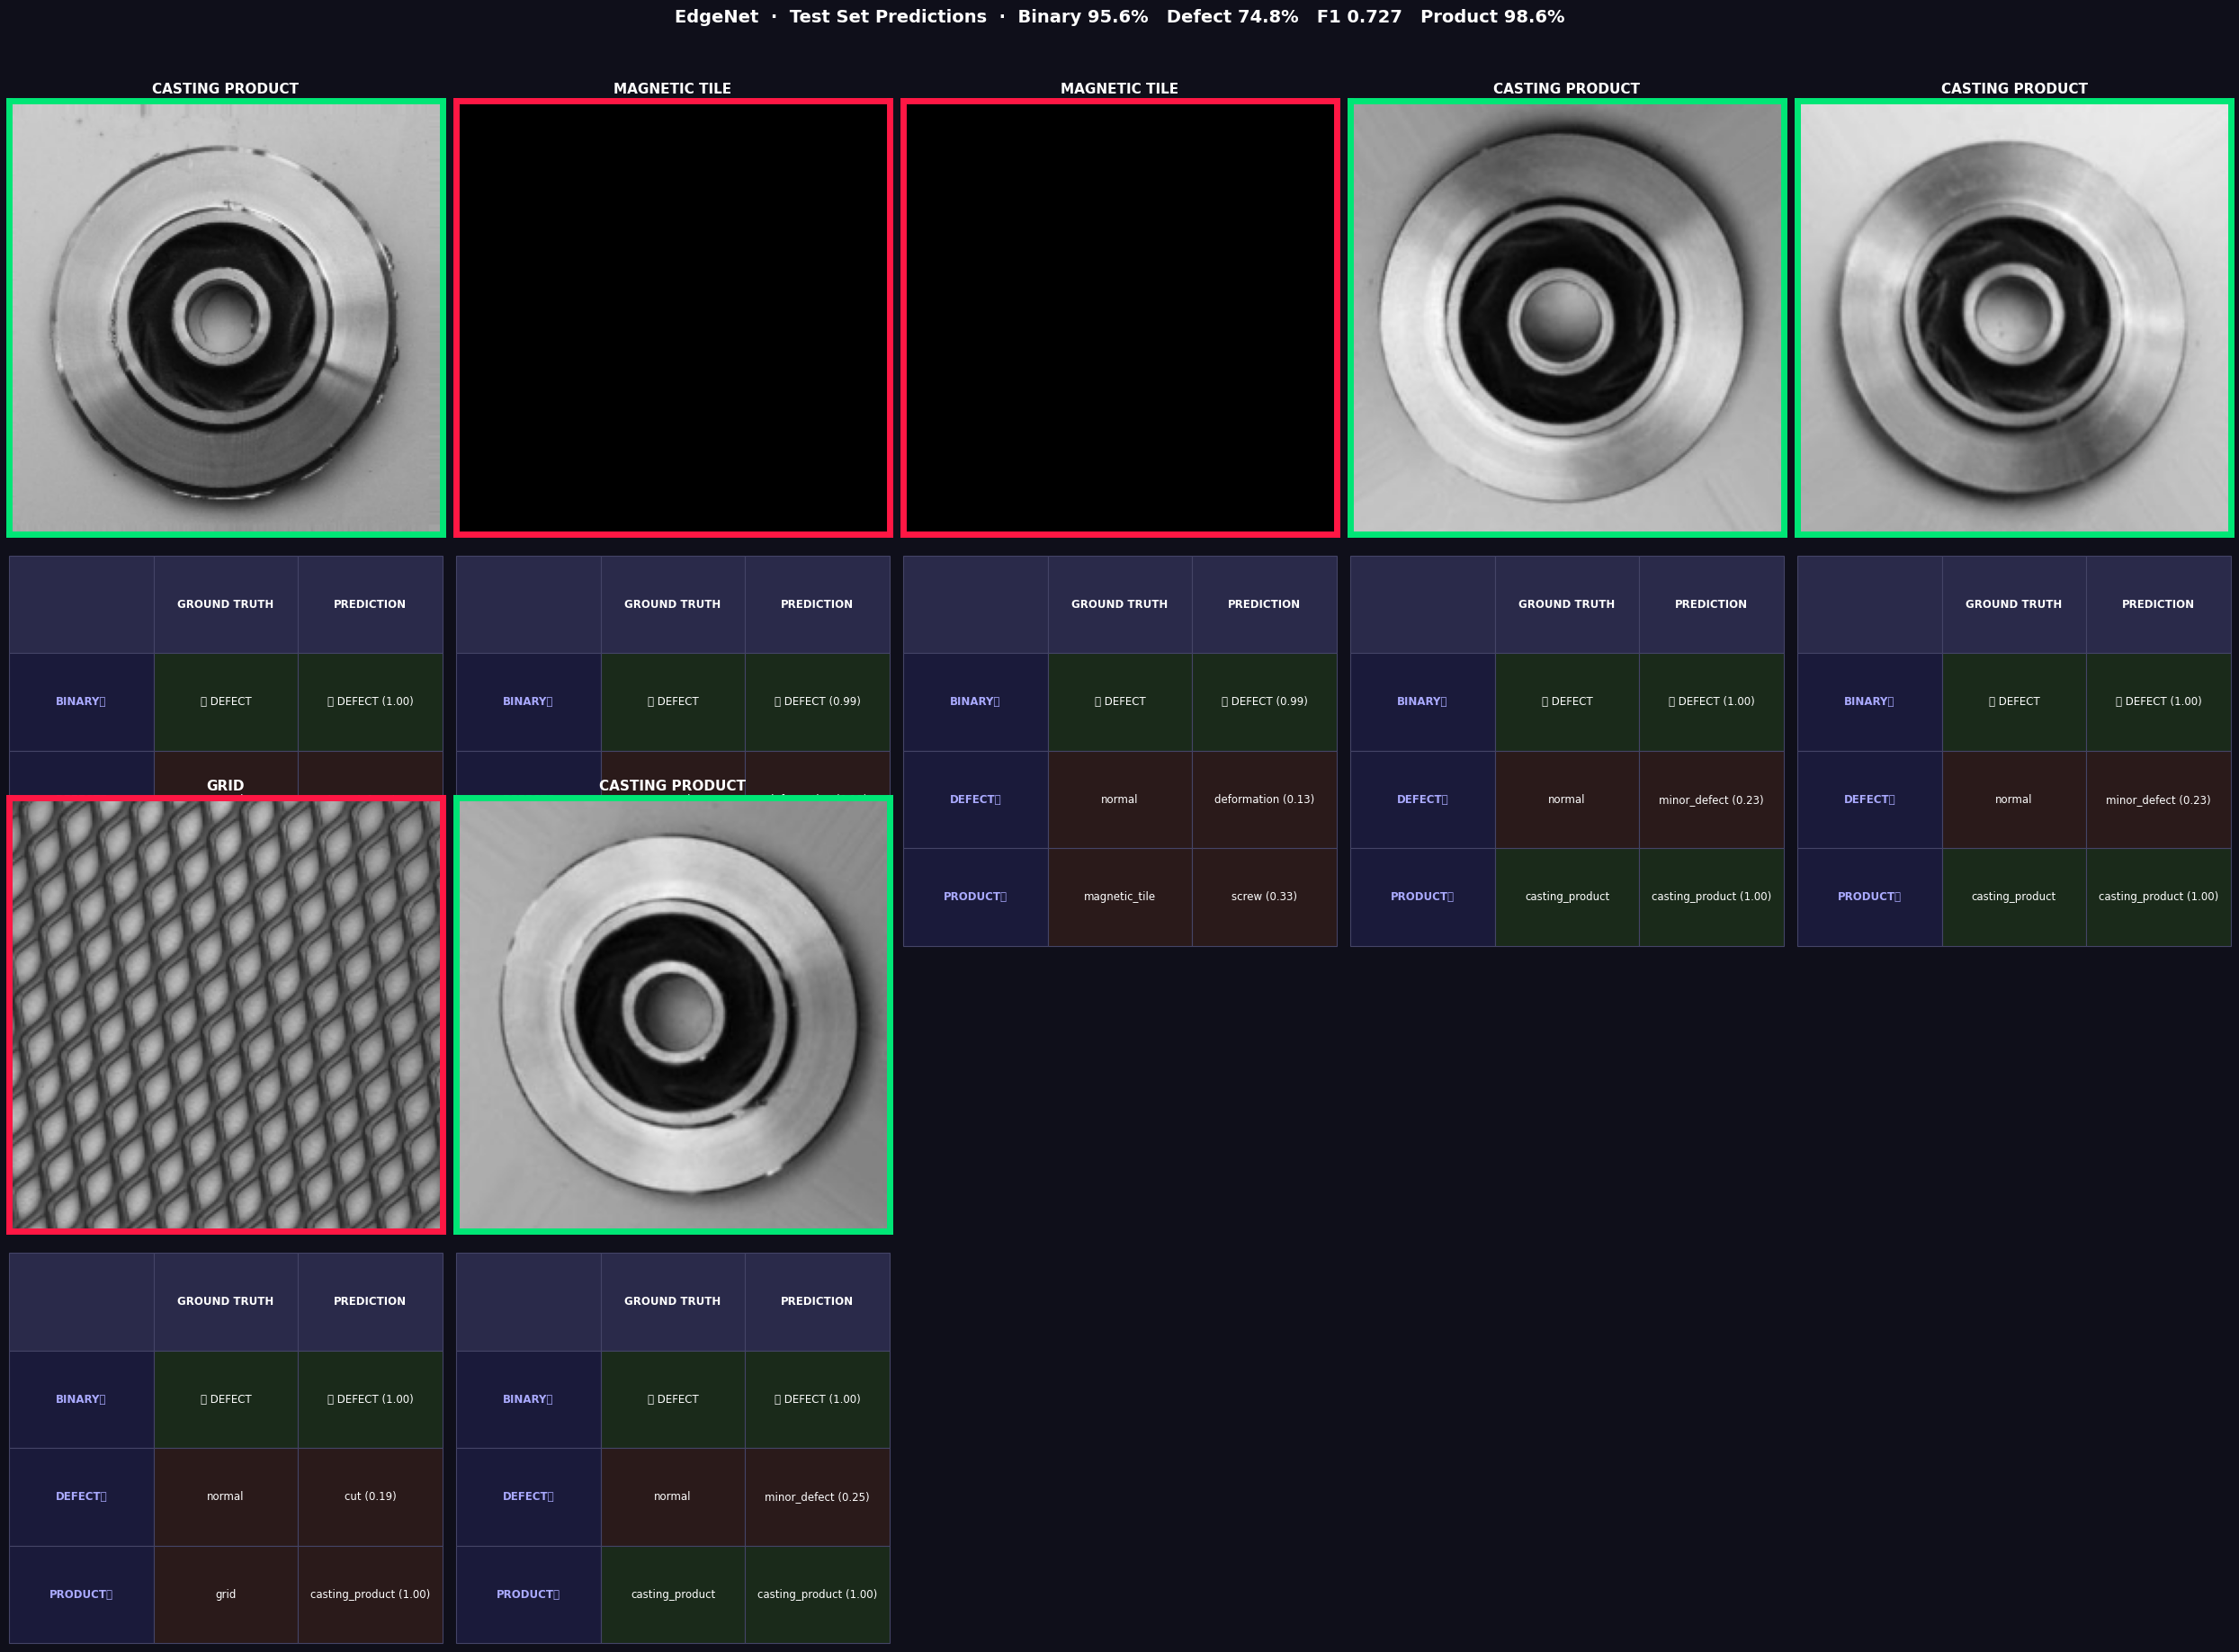

✅ Saved → /home/sufi/edgenet_predictions.png  (seed=1773504874)


In [28]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  VISUALIZATION CELL — Random Test Predictions vs Ground Truth       ║
# ╚══════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn.functional as F
import cv2
from PIL import Image
import torchvision.transforms as transforms
import time

# ── Config ────────────────────────────────────────────────────────────
N_IMAGES  = 10
THRESHOLD = 0.5
COLS      = 5
ROWS      = N_IMAGES // COLS

# ── Truly random sample every run ────────────────────────────────────
SEED = int(time.time())   # different every run
rng  = np.random.default_rng(SEED)

defect_idx = test_df[test_df['binary_label'] == 1].index.tolist()
normal_idx = test_df[test_df['binary_label'] == 0].index.tolist()

n_defect = 7
n_normal = N_IMAGES - n_defect

picked = (
    rng.choice(defect_idx, size=min(n_defect, len(defect_idx)), replace=False).tolist() +
    rng.choice(normal_idx, size=min(n_normal, len(normal_idx)), replace=False).tolist()
)
rng.shuffle(picked)
sample_df = test_df.loc[picked].reset_index(drop=True)

# ── Transform ─────────────────────────────────────────────────────────
_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Inference ─────────────────────────────────────────────────────────
model.eval()
results = []

with torch.no_grad():
    for _, row in sample_df.iterrows():
        img_bgr = cv2.imread(row['image_path'])
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        tensor  = _tf(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

        bin_out, def_out, prod_out = model(tensor)
        bin_prob  = torch.sigmoid(bin_out).item()
        is_defect = bin_prob > THRESHOLD
        def_probs  = F.softmax(def_out,  dim=1).squeeze().cpu().numpy()
        prod_probs = F.softmax(prod_out, dim=1).squeeze().cpu().numpy()
        pred_def   = int(def_probs.argmax())
        pred_prod  = int(prod_probs.argmax())

        gt_binary = int(row['binary_label'])
        gt_def    = int(row['defect_type_label'])
        gt_prod   = int(row['product_type_label'])

        correct_bin  = int(is_defect) == gt_binary
        correct_def  = (
            (pred_def == gt_def) if (gt_def != -1 and is_defect)
            else (not is_defect and gt_binary == 0)
        )
        correct_prod = pred_prod == gt_prod

        results.append({
            'img'         : cv2.resize(img_rgb, (224, 224)),
            'gt_binary'   : gt_binary,
            'gt_def'      : SEMANTIC_GROUPS[gt_def] if gt_def != -1 else 'normal',
            'gt_prod'     : IDX_TO_PRODUCT_TYPE[gt_prod],
            'pred_binary' : int(is_defect),
            'pred_def'    : SEMANTIC_GROUPS[pred_def] if is_defect else 'normal',
            'pred_prod'   : IDX_TO_PRODUCT_TYPE[pred_prod],
            'bin_prob'    : bin_prob,
            'def_conf'    : float(def_probs[pred_def]),
            'prod_conf'   : float(prod_probs[pred_prod]),
            'correct_bin' : correct_bin,
            'correct_def' : correct_def,
            'correct_prod': correct_prod,
        })

# ── Plot ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(COLS * 5, ROWS * 8))
fig.patch.set_facecolor('#0f0f1a')

for i, r in enumerate(results[:N_IMAGES]):
    ax = fig.add_subplot(ROWS, COLS, i + 1)

    ax.imshow(r['img'])
    ax.set_xticks([]); ax.set_yticks([])

    # border
    all_ok     = r['correct_bin'] and r['correct_prod']
    border_col = '#00e676' if all_ok else '#ff1744'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_col)
        spine.set_linewidth(5)

    # product name as title
    ax.set_title(
        r['gt_prod'].replace('_', ' ').upper(),
        fontsize=11, fontweight='bold',
        color='white', pad=6,
    )

    # ── build label rows ─────────────────────────────────────────
    gt_b   = '🔴 DEFECT' if r['gt_binary']   else '🟢 NORMAL'
    pr_b   = '🔴 DEFECT' if r['pred_binary']  else '🟢 NORMAL'
    b_tick = '✅' if r['correct_bin']  else '❌'
    d_tick = '✅' if r['correct_def']  else '❌'
    p_tick = '✅' if r['correct_prod'] else '❌'

    # each row: label | GT value | PRED value
    rows = [
        ('',        'GROUND TRUTH',       'PREDICTION'),
        ('BINARY'+b_tick,  gt_b,          f"{pr_b} ({r['bin_prob']:.2f})"),
        ('DEFECT'+d_tick,  r['gt_def'],   f"{r['pred_def']} ({r['def_conf']:.2f})"),
        ('PRODUCT'+p_tick, r['gt_prod'],  f"{r['pred_prod']} ({r['prod_conf']:.2f})"),
    ]

    col_colors_header = ['#2a2a4a', '#1e3a2e', '#1e2a3e']
    row_colors = [
        ['#2a2a4a', '#2a2a4a', '#2a2a4a'],
        ['#1a1a3a', '#1a2a1a' if r['correct_bin']  else '#2a1a1a',
                    '#1a2a1a' if r['correct_bin']  else '#2a1a1a'],
        ['#1a1a3a', '#1a2a1a' if r['correct_def']  else '#2a1a1a',
                    '#1a2a1a' if r['correct_def']  else '#2a1a1a'],
        ['#1a1a3a', '#1a2a1a' if r['correct_prod'] else '#2a1a1a',
                    '#1a2a1a' if r['correct_prod'] else '#2a1a1a'],
    ]

    # ── draw table below image ────────────────────────────────────
    table = ax.table(
        cellText   = rows,
        cellLoc    = 'center',
        loc        = 'bottom',
        bbox       = [0, -0.95, 1, 0.90],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor('#444466')
        cell.set_linewidth(0.8)
        cell.set_facecolor(row_colors[row_idx][col_idx])
        cell.set_text_props(color='white', fontweight='bold' if row_idx == 0 else 'normal')
        if col_idx == 0:
            cell.set_text_props(color='#aaaaff', fontweight='bold')

plt.suptitle(
    f'EdgeNet  ·  Test Set Predictions  ·  '
    f'Binary {ck["val_metrics"]["binary_acc"]:.1f}%   '
    f'Defect {ck["val_metrics"]["defect_acc"]:.1f}%   '
    f'F1 {ck["val_metrics"]["defect_f1_macro"]:.3f}   '
    f'Product {ck["val_metrics"]["product_acc"]:.1f}%',
    fontsize=14, color='white', fontweight='bold', y=1.01,
)

plt.tight_layout()
save_path = '/home/sufi/edgenet_predictions.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print(f"✅ Saved → {save_path}  (seed={SEED})")